In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, classification_report,
                             roc_auc_score, RocCurveDisplay, auc,silhouette_score,
                             adjusted_rand_score,precision_recall_curve,
                             average_precision_score,roc_curve)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Project Sections

## Table of Contents

1. [Data Loading](#data-loading)

2. [Feature Selection](#feature-selection)

3. [Isolation Forest](#isolation-forest)

4. [XGBoosting](#xgboosting)

5. [Light GBM](#light-gbm)

6. [Sentinel Species](#sentinel-species)

7. [MLP Neural Network](#mlp-neural-network)

# Data Loading

In [ ]:
import pandas as pd
import glob
import os

# 1. Define the folder containing your 6 Audio Moth CSV files
# Make sure to update this path to the correct folder!
csv_folder_path = "/content/drive/MyDrive/KWF/Audio Moth Data/Audio Features/"

# Find all .csv files in that directory
csv_files = glob.glob(os.path.join(csv_folder_path, "*.csv"))
print(f"Found {len(csv_files)} CSV files.")

# 2. Read and combine all CSVs
df_list = []
for file in csv_files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

# Concatenate into one massive DataFrame
df = pd.concat(df_list, ignore_index=True)
print(f"Combined DataFrame shape before cleanup: {df.shape}")

# 3. Define the entries to delete (the 4 from the email)
files_to_drop = [
    'Audio_Moth_6_20250317_140803.wav',
    'Audio_Moth_6_20250317_140806.wav',
    'Audio_Moth_6_20250317_140809.wav',
    'Audio_Moth_6_20250317_140812.wav'
]

# 4. Filter the dataframe to drop those specific rows
target_column = 'clip_name'

# The ~ symbol means "NOT". So this keeps rows that are NOT in the drop list.
df = df[~df[target_column].isin(files_to_drop)]

print(f"Combined DataFrame shape after cleanup:  {df.shape}")

# 5. Check the final info
df.info()

Found 4 CSV files.
Combined DataFrame shape before cleanup: (464950, 68)
Combined DataFrame shape after cleanup:  (464950, 68)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464950 entries, 0 to 464949
Data columns (total 68 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   clip_name                 464950 non-null  object 
 1   Spectral RMS Energy       464950 non-null  float64
 2   Zero Crossing Rate        464950 non-null  float64
 3   Spectral Bandwidth        464950 non-null  float64
 4   Spectral Rolloff (85%)    464950 non-null  float64
 5   Spectral Flatness         464950 non-null  float64
 6   Onset Strength            464950 non-null  float64
 7   Spectral Contrast         464950 non-null  float64
 8   Spectral_Contrast_Band_1  464950 non-null  float64
 9   Spectral_Contrast_Band_2  464950 non-null  float64
 10  Spectral_Contrast_Band_3  464950 non-null  float64
 11  Spectral_Contrast_Band_4  464

In [ ]:
# 1. Load the bioacoustics dataset
bio_path = "/content/drive/MyDrive/KWF/Audio Moth Data/bioacoustics_dataset.csv"
bio_df = pd.read_csv(bio_path)

print(f"Loaded Bioacoustics data: {bio_df.shape}")

# 2. Select only the columns you want to bring over
# If you merge the entire bio_df, you might end up with duplicate columns
# (like 'start_time_x' and 'start_time_y').
# It is cleaner to only grab the join key ('clip_name') and the specific weather columns.
weather_columns = [
    'clip_name',     # MUST include the join key
    'Recorder',
    'Timestamp',
    'Human Activity',
    'Human Activity Score',
    'species',
    'confidence',
    'Sim Type',
    'Sim Relative Time',
    'Temperature',
    'Windspeed',
    'Precipitation',
    'Humidity',
    'Weathercode',
    'Weather Desc',
    'Timestamp Local',
    'Sunrise',
    'Sunset',
    'Time Of Day',
    'Timestamp UTC',
    'Datetime'
]

# Ensure we only try to pull columns that actually exist in bio_df
available_weather_cols = [col for col in weather_columns if col in bio_df.columns]
bio_weather_subset = bio_df[available_weather_cols]

# 3. Perform the Merge (Left Join)
# 'df' is your combined and cleaned dataframe from the previous step.
# how='left' ensures we don't lose any audio segments, even if they lack weather data.
final_df = pd.merge(
    df,
    bio_weather_subset,
    on='clip_name',
    how='left'
)

print(f"Final DataFrame shape after merge: {final_df.shape}")

# 4. Verification Check
# Let's check if any rows failed to find matching weather data
missing_weather = final_df['Temperature'].isna().sum()
print(f"Rows missing weather data after merge: {missing_weather}")

# Preview the combined data
final_df.head()

Loaded Bioacoustics data: (631321, 32)
Final DataFrame shape after merge: (464950, 88)
Rows missing weather data after merge: 0


,clip_name,Spectral RMS Energy,Zero Crossing Rate,Spectral Bandwidth,Spectral Rolloff (85%),Spectral Flatness,Onset Strength,Spectral Contrast,Spectral_Contrast_Band_1,Spectral_Contrast_Band_2,...,Precipitation,Humidity,Weathercode,Weather Desc,Timestamp Local,Sunrise,Sunset,Time Of Day,Timestamp UTC,Datetime
0,Audio_Moth_1_20250317_125112.wav,0.010311,0.667359,5976.218072,19678.440824,0.155557,1.046151,12.299363,8.686644,7.955534,...,0.0,67,3,Overcast,2025-03-17 13:00:00-06:00,2025-03-17 05:40:20.789893-06:00,2025-03-17 17:45:19.173328-06:00,afternoon,2025-03-17 19:00:00+00:00,2025-03-17 13:00:00
1,Audio_Moth_1_20250317_125115.wav,0.007129,0.547947,6636.419755,19434.092420,0.281403,1.100655,12.091351,9.391381,7.529761,...,0.0,67,3,Overcast,2025-03-17 13:00:00-06:00,2025-03-17 05:40:20.789893-06:00,2025-03-17 17:45:19.173328-06:00,afternoon,2025-03-17 19:00:00+00:00,2025-03-17 13:00:00
2,Audio_Moth_1_20250317_125118.wav,0.005902,0.458676,6964.411801,19402.011303,0.359520,1.129146,11.953613,9.498127,7.855621,...,0.0,67,3,Overcast,2025-03-17 13:00:00-06:00,2025-03-17 05:40:20.789893-06:00,2025-03-17 17:45:19.173328-06:00,afternoon,2025-03-17 19:00:00+00:00,2025-03-17 13:00:00
3,Audio_Moth_1_20250317_125121.wav,0.005952,0.516643,6927.946612,19654.255319,0.333466,1.076708,12.038439,9.785964,7.913269,...,0.0,67,3,Overcast,2025-03-17 13:00:00-06:00,2025-03-17 05:40:20.789893-06:00,2025-03-17 17:45:19.173328-06:00,afternoon,2025-03-17 19:00:00+00:00,2025-03-17 13:00:00
4,Audio_Moth_1_20250317_125124.wav,0.007983,0.620645,6483.752196,19708.194814,0.227566,1.051963,12.341645,9.653348,8.211192,...,0.0,67,3,Overcast,2025-03-17 13:00:00-06:00,2025-03-17 05:40:20.789893-06:00,2025-03-17 17:45:19.173328-06:00,afternoon,2025-03-17 19:00:00+00:00,2025-03-17 13:00:00


In [ ]:
final_df['species'].unique()
df = final_df.copy()

### Rationale for Top 10 Sentinel Species Selection
The original three manually selected sentinel species flatlined in permutation importance because they had massive sample sizes (e.g., n > 1000) but less than 1% correlation to human presence, acting as constant background noise to the model.

To improve model predictions, we replaced them with a Top 10 list derived from heatmap analysis that hits the "sweet spot": a high enough frequency for the model to learn from, coupled with a meaningful correlation percentage to act as a true trigger.

**1. The "Heavyweights" (Massive Volume + Good Correlation)**
* **Buff-rumped Warbler:** The ultimate volume candidate. Provides a massive, consistent baseline of human-correlated events across multiple sensors (e.g., n=5816 / 1.4% on AM6).
* **Black-cheeked Ant-Tanager:** Massive volume on AM2 (n=4544) with a solid 1.0% correlation.
* **Black-hooded Antshrike:** Strong volume on AM1 (n=2491) and a 1.9% correlation.
* **Great Tinamou:** Strong baseline on AM2 (n=1838) and a 1.8% correlation.

**2. The "High-Signal" Sentinels (Medium Volume + High Correlation)**
* **Short-billed Pigeon:** A phenomenal candidate. Highly significant 10.7% correlation across a healthy sample size (n=680) on AM1.
* **Yellow-throated Toucan:** A very strong localized trigger. Shows a 17.2% correlation (n=93) on AM6.
* **Blue-black Grosbeak:** Another strong localized trigger on AM1, showing a 7.2% correlation (n=195).

**3. The "Consistent Indicators" (Medium Volume + Steady Correlation)**
* **Rufous Piha:** Solid numbers on AM4, with a 2.7% correlation (n=620).
* **Band-tailed Barbthroat:** Steady correlations on AM4 and AM6.
* **Scarlet Macaw:** Consistently pops up across multiple sensors during human activity.

In [ ]:
import pandas as pd
import numpy as np
import ast

# ==========================================
# HELPER: Safe List Evaluator
# ==========================================
def safe_eval(val):
    if isinstance(val, list):
        return val
    if pd.isna(val) or str(val).strip() == "":
        return []
    try:
        result = ast.literal_eval(str(val))
        if isinstance(result, list):
            return result
        return [result]
    except (ValueError, SyntaxError):
        return []

# ==========================================
# 1. DATETIME CONVERSION
# ==========================================
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

# ==========================================
# 2. CREATE TEMPORARY LIST COLUMNS
# ==========================================
if 'species' in df.columns:
    df['parsed_species'] = df['species'].apply(safe_eval)
if 'confidence' in df.columns:
    df['parsed_confidence'] = df['confidence'].apply(safe_eval)
if 'Sim Type' in df.columns:
    df['parsed_sim_type'] = df['Sim Type'].apply(safe_eval)
if 'Sim Relative Time' in df.columns:
    df['parsed_sim_time'] = df['Sim Relative Time'].apply(safe_eval)

# ==========================================
# 3. EXPLODE SIMULATIONS
# ==========================================
df = df.explode(['parsed_sim_type', 'parsed_sim_time'])

# ==========================================
# 4. SIMULATION TIME "DECAY"
# ==========================================
def calculate_single_decay(t, tau=60.0):
    if pd.isna(t) or str(t).strip() == "":
        return 0.0
    try:
        return np.exp(-abs(float(t)) / tau)
    except (ValueError, TypeError):
        return 0.0

df['Sim_Influence_Score'] = df['parsed_sim_time'].apply(calculate_single_decay)

# ==========================================
# 5. ENCODING
# ==========================================
# Updated to the Top 10 data-driven sentinel species
target_species = [
    'Myiothlypis fulvicauda_Buff-rumped Warbler',
    'Habia atrimaxillaris_Black-cheeked Ant-Tanager',
    'Thamnophilus bridgesi_Black-hooded Antshrike',
    'Tinamus major_Great Tinamou',
    'Patagioenas nigrirostris_Short-billed Pigeon',
    'Ramphastos ambiguus_Yellow-throated Toucan',
    'Cyanoloxia cyanoides_Blue-black Grosbeak',
    'Lipaugus unirufus_Rufous Piha',
    'Threnetes ruckeri_Band-tailed Barbthroat',
    'Ara macao_Scarlet Macaw'
]

target_sims = ['Human Presence on Trail', 'Vehicle', 'Gunshot', 'Chainsaw', 'Human Presence off Trail']

# A. Species Many-Hot Encoding
def multi_hot_encode(df, source_col, target_list):
    for target in target_list:
        df[target] = df[source_col].apply(lambda x: 1 if isinstance(x, list) and target in x else 0)
    return df

df = multi_hot_encode(df, 'parsed_species', target_species)

# B. Sim Type One-Hot Encoding
sim_dummies = pd.get_dummies(df['parsed_sim_type'])
for sim in target_sims:
    if sim in sim_dummies.columns:
        df[sim] = sim_dummies[sim].astype(int)
    else:
        df[sim] = 0

# ==========================================
# 6. CLEANUP & RENAMING
# ==========================================
# 1. Rename the original string columns
df.rename(columns={
    'Sim Type': 'Old_Sim_Type',
    'Sim Relative Time': 'Old_Sim_Relative_Time'
}, inplace=True)

# 2. Rename the exploded parsed columns to take over the primary names
df.rename(columns={
    'parsed_sim_type': 'Sim Type',
    'parsed_sim_time': 'Sim Relative Time'
}, inplace=True)

# 3. Drop only the temporary species/confidence columns
df = df.drop(columns=['parsed_species', 'parsed_confidence'], errors='ignore')

print(f"Pipeline complete. New shape: {df.shape}")

Pipeline complete. New shape: (467488, 106)


In [ ]:
df['Sim Type'].unique()

array([nan, 'Vehicle', 'Human Presence on Trail', 'Gunshot', 'Chainsaw',
       'Human Presence off Trail'], dtype=object)

due to the merge, **Sim Type** and **Species** is a list that is not hashable, **Sim Type** will be exploded alongside **Sim Relative Time**, and **Species** along with its **confidence** will be Multi-encoded, but it means that it will stay as a list, which isn't necessary for the model but could be helpful for readability, model will be utilizing the multi-encoded column

In [ ]:
df['species'].unique()

array(['[]', "['Thamnophilus bridgesi_Black-hooded Antshrike']",
       "['Ramphocaenus melanurus_Long-billed Gnatwren']",
       "['Microcerculus marginatus_Scaly-breasted Wren']",
       "['Arremon aurantiirostris_Orange-billed Sparrow']",
       "['Patagioenas nigrirostris_Short-billed Pigeon']",
       "['Myiornis atricapillus_Black-capped Pygmy-Tyrant']",
       "['Epinecrophylla fulviventris_Checker-throated Stipplethroat']",
       "['Euphonia hirundinacea_Yellow-throated Euphonia']",
       "['Contopus sordidulus_Western Wood-Pewee']",
       "['Contopus virens_Eastern Wood-Pewee']",
       "['Cantorchilus semibadius_Riverside Wren']",
       "['Thamnophilus bridgesi_Black-hooded Antshrike', 'Cantorchilus semibadius_Riverside Wren']",
       "['Loriotus luctuosus_White-shouldered Tanager']",
       "['Hylophylax naevioides_Spotted Antbird']",
       "['Ramphocaenus melanurus_Long-billed Gnatwren', 'Thamnophilus bridgesi_Black-hooded Antshrike']",
       "['Tyrannus savana_Fork-

In [ ]:
sentinel_species_cols = [
    'Myiothlypis fulvicauda_Buff-rumped Warbler',
    'Habia atrimaxillaris_Black-cheeked Ant-Tanager',
    'Thamnophilus bridgesi_Black-hooded Antshrike',
    'Tinamus major_Great Tinamou',
    'Patagioenas nigrirostris_Short-billed Pigeon',
    'Ramphastos ambiguus_Yellow-throated Toucan',
    'Cyanoloxia cyanoides_Blue-black Grosbeak',
    'Lipaugus unirufus_Rufous Piha',
    'Threnetes ruckeri_Band-tailed Barbthroat',
    'Ara macao_Scarlet Macaw'
]

display(df[sentinel_species_cols].head())

,Myiothlypis fulvicauda_Buff-rumped Warbler,Habia atrimaxillaris_Black-cheeked Ant-Tanager,Thamnophilus bridgesi_Black-hooded Antshrike,Tinamus major_Great Tinamou,Patagioenas nigrirostris_Short-billed Pigeon,Ramphastos ambiguus_Yellow-throated Toucan,Cyanoloxia cyanoides_Blue-black Grosbeak,Lipaugus unirufus_Rufous Piha,Threnetes ruckeri_Band-tailed Barbthroat,Ara macao_Scarlet Macaw
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


Incorpoating Patrick's Changes

In [ ]:
import numpy as np

print("Incorporating Patrick's engineered features (Updated for Top 10 Sentinels)...")

# 1. Cyclical Time Transformation
if 'Datetime_hour' not in df.columns:
    df['Datetime_hour'] = df['Datetime'].dt.hour
df['hour_sin'] = np.sin(df['Datetime_hour'] * (2 * np.pi / 24))
df['hour_cos'] = np.cos(df['Datetime_hour'] * (2 * np.pi / 24))

# 2. Creating a silence signal (Eerie Silence)
# Define the new top 10 list
sentinel_species_cols = [
    'Myiothlypis fulvicauda_Buff-rumped Warbler',
    'Habia atrimaxillaris_Black-cheeked Ant-Tanager',
    'Thamnophilus bridgesi_Black-hooded Antshrike',
    'Tinamus major_Great Tinamou',
    'Patagioenas nigrirostris_Short-billed Pigeon',
    'Ramphastos ambiguus_Yellow-throated Toucan',
    'Cyanoloxia cyanoides_Blue-black Grosbeak',
    'Lipaugus unirufus_Rufous Piha',
    'Threnetes ruckeri_Band-tailed Barbthroat',
    'Ara macao_Scarlet Macaw'
]

# If the sum of all 10 columns is 0, it means none of the sentinels were detected
df['Eerie_Silence'] = (df[sentinel_species_cols].sum(axis=1) == 0).astype(int)

# 3. Weather vs. Anomaly Separation (Volume to Wind Ratio)
# Using a tiny epsilon (1e-5) to avoid dividing by zero
df['Volume_Wind_Ratio'] = df['Spectral RMS Energy'] / (df['Windspeed'] + 1e-5)

# 4. Signaling sudden acoustic changes (15-second memory)
# First, sort logically by recorder and time to ensure sequential order
df = df.sort_values(by=['Recorder', 'Datetime']).reset_index(drop=True)

# Since clips are 3 seconds, a 15-second memory uses a window of 5
df['Rolling_Vol_15s'] = df.groupby('Recorder')['Spectral RMS Energy'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean()
)
df['Volume_Spike_15s'] = df['Spectral RMS Energy'] - df['Rolling_Vol_15s']
df['Volume_Spike_15s'] = df['Volume_Spike_15s'].fillna(0)

print("Patrick's features added successfully!")

Incorporating Patrick's engineered features (Updated for Top 10 Sentinels)...
Patrick's features added successfully!


## Feature Selection

In [ ]:
audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]

# The actual column name for RMS Energy is 'Spectral RMS Energy'
core_features = [
    'Spectral RMS Energy',
    'Spectral Contrast', 'Spectral Flatness',
    'Spectral Bandwidth', 'Spectral Rolloff (85%)',
    'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13'
]

# These are the actual column names created by multi_hot_encode in cell
sentinel_species_cols = [
    'Myiothlypis fulvicauda_Buff-rumped Warbler',
    'Habia atrimaxillaris_Black-cheeked Ant-Tanager',
    'Thamnophilus bridgesi_Black-hooded Antshrike',
    'Tinamus major_Great Tinamou',
    'Patagioenas nigrirostris_Short-billed Pigeon',
    'Ramphastos ambiguus_Yellow-throated Toucan',
    'Cyanoloxia cyanoides_Blue-black Grosbeak',
    'Lipaugus unirufus_Rufous Piha',
    'Threnetes ruckeri_Band-tailed Barbthroat',
    'Ara macao_Scarlet Macaw'
]

sentinel_features = sentinel_species_cols

# NEW: Grouping Patrick's engineered features
patrick_features = [
    'hour_sin', 'hour_cos', 'Eerie_Silence',
    'Volume_Wind_Ratio', 'Volume_Spike_15s'
]

# Modified to include Patrick's features, replacing Datetime_hour with the cyclical versions
expanded_features = core_features + \
    sentinel_species_cols + \
    patrick_features + \
    [
    'Temperature', 'Humidity', 'Windspeed',
    'Human Activity Score', 'confidence'
]

combined_features = core_features + sentinel_species_cols

# Modified custom features to include the new signals
custom_features = \
    sentinel_species_cols + \
    patrick_features + \
    [
    'Windspeed', 'Temperature',
    'Spectral RMS Energy',
    'Humidity', 'MFCC_12'
]

# Corrected logic: is_simulation should be 1 if Sim Type is NOT NaN (meaning a simulation occurred)
df['is_simulation'] = df['Sim Type'].notna().astype(int)

# Added Patrick's suggested weight factor as a variable for the XGBoost iterations
patrick_scale_pos_weight = 114

def plot_feature_importance(model, feature_names, title):
    """
    Creates and displays a bar plot of feature importances.

    Args:
        model: A trained machine learning model with a .feature_importances_ attribute.
        feature_names (list or pd.Index): The names of the features.
        title (str): The title for the plot.
    """
    # Create a DataFrame with features and their importance scores
    importances = model.feature_importances_;
    feature_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

    # Set plot titles and labels
    plt.title(title, fontsize=16)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_test, y_test, feature_names, title):
    """
    Calculates and displays a bar plot of permutation feature importances.

    Args:
        model: A trained scikit-learn model.
        X_test (pd.DataFrame or np.array): The test features.
        y_test (pd.Series or np.array): The test labels.
        feature_names (list or pd.Index): The names of the features.
        title (str): The title for the plot.
    """
    print("Calculating permutation importance...")

    # Calculate permutation importance
    # We use 'f1' as the scoring metric since that's what you're optimizing for
    result = permutation_importance(
        model, X_test, y_test, n_repeats=10, random_state=42, scoring='f1'
    )

    # Create a DataFrame with features and their importance scores
    importances = result.importances_mean
    feature_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

    # Set plot titles and labels
    plt.title(title, fontsize=16)
    plt.xlabel('Importance Score (Decrease in F1-Score)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()

print(f"Total samples:      {len(df)}")
print(f"Simulation samples: {df['is_simulation'].sum()}")
print(f"Baseline samples:   {(df['is_simulation'] == 0).sum()}")
print(f"\nSimulation types:\n{df['Sim Type'].value_counts()}")

Total samples:      467488
Simulation samples: 11708
Baseline samples:   455780

Simulation types:
Sim Type
Human Presence on Trail     8834
Vehicle                     1137
Gunshot                     1035
Chainsaw                     601
Human Presence off Trail     101
Name: count, dtype: int64


In [ ]:
X = df[core_features].copy()
y = df['is_simulation'].copy()
print(f"Missing values in features: {X.isnull().sum().sum()}")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set - Simulation: {y_train.sum()}, Baseline: {(y_train == 0).sum()}")
print(f"Test set - Simulation: {y_test.sum()}, Baseline: {(y_test == 0).sum()}")

Missing values in features: 0
Train set - Simulation: 9366, Baseline: 364624
Test set - Simulation: 2342, Baseline: 91156


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scale_pos_weight = (y_train == 0).sum() / y_train.sum()
# Using Patrick's suggested weights to reduce false positives
scale_pos_weight = patrick_scale_pos_weight
print(f"Scale pos weight: {scale_pos_weight:.2f}")


Scale pos weight: 114.00


In [ ]:
df = df.rename(columns={'Recorder': 'recorder_id'})
#Dataset A: Audio_Moth_1 only (open area)
df_moth1 = df[df['recorder_id'] == 'Audio_Moth_1'].copy()
print(f"Dataset A (Audio_Moth_1 - open area): {df_moth1.shape[0]} samples")

#Dataset B: All Audio_Moth recorders (including moth1)
df_all_moths = df[df['recorder_id'].str.contains('Audio_Moth', na=False)].copy()
print(f"Dataset B (All Audio_Moth recorders): {df_all_moths.shape[0]} samples")

print(f"\nTotal samples: {len(df)}")
print(f"Unique recorders: {df['recorder_id'].unique()}")
print(f"Audio_Moth recorders: {df_all_moths['recorder_id'].unique()}")

def prepare_features(df_input, dataset_name):
    print(f"\n=== {dataset_name} ===")

    # Reset index to ensure a unique, default index, crucial after 'explode' operations
    df_processed = df_input.reset_index(drop=True).copy()

    # Identify rows that are clean based on core_features
    # Replace inf/-inf with NaN and then find rows where *any* core_feature is NaN
    valid_mask = ~df_processed[core_features].replace([np.inf, -np.inf], np.nan).isnull().any(axis=1)

    # Filter the processed DataFrame using this mask
    df_subset_cleaned = df_processed[valid_mask].copy()

    # X should be the values of core_features from this cleaned and aligned subset
    X = df_subset_cleaned[core_features].values

    print(f"Shape after cleaning: {df_subset_cleaned.shape}")
    print(f"Simulation samples: {df_subset_cleaned['is_simulation'].sum()} ({df_subset_cleaned['is_simulation'].mean():.2%})")

    return df_subset_cleaned, X

df_A, X_A = prepare_features(df_moth1, "Audio_Moth_1 (open area)")
df_B, X_B = prepare_features(df_all_moths, "All Audio_Moth recorders")

Dataset A (Audio_Moth_1 - open area): 111684 samples
Dataset B (All Audio_Moth recorders): 467488 samples

Total samples: 467488
Unique recorders: ['Audio_Moth_1' 'Audio_Moth_4' 'Audio_Moth_5' 'Audio_Moth_6']
Audio_Moth recorders: ['Audio_Moth_1' 'Audio_Moth_4' 'Audio_Moth_5' 'Audio_Moth_6']

=== Audio_Moth_1 (open area) ===
Shape after cleaning: (111684, 114)
Simulation samples: 1102 (0.99%)

=== All Audio_Moth recorders ===
Shape after cleaning: (467488, 114)
Simulation samples: 11708 (2.50%)


In [ ]:
from sklearn.cluster import DBSCAN

def perform_pca_analysis(X, df_subset, dataset_name):
    """Perform PCA analysis and return transformed data"""
    print(f"\n=== PCA Analysis for {dataset_name} ===")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca_full = PCA(random_state=42)
    pca_full.fit(X_scaled)

    print("Explained variance ratio by component:")
    for i, ratio in enumerate(pca_full.explained_variance_ratio_):
        print(f"Component {i+1}: {ratio:.2%} ({np.sum(pca_full.explained_variance_ratio_[:i+1]):.2%} cumulative)")

    n_components_90 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.90) + 1
    print(f"Components needed for 90% variance: {n_components_90}")

    pca_cluster = PCA(n_components=min(5, len(core_features)), random_state=42)
    pca_viz = PCA(n_components=2, random_state=42)

    X_pca_cluster = pca_cluster.fit_transform(X_scaled)
    X_pca_viz = pca_viz.fit_transform(X_scaled)

    df_subset_copy = df_subset.copy()
    df_subset_copy['pca1'] = X_pca_viz[:, 0]
    df_subset_copy['pca2'] = X_pca_viz[:, 1]

    print(f"PCA clustering components explained variance: {pca_cluster.explained_variance_ratio_.sum():.2%}")
    print(f"PCA visualization components explained variance: {pca_viz.explained_variance_ratio_.sum():.2%}")

    return X_scaled, X_pca_cluster, X_pca_viz, df_subset_copy, scaler, pca_cluster, pca_viz

results_A = perform_pca_analysis(X_A, df_A, "Audio_Moth_1 (open area)")
X_A_scaled, X_A_pca_cluster, X_A_pca_viz, df_A_pca, scaler_A, pca_cluster_A, pca_viz_A = results_A

results_B = perform_pca_analysis(X_B, df_B, "All Audio_Moth recorders")
X_B_scaled, X_B_pca_cluster, X_B_pca_viz, df_B_pca, scaler_B, pca_cluster_B, pca_viz_B = results_B


=== PCA Analysis for Audio_Moth_1 (open area) ===
Explained variance ratio by component:
Component 1: 36.80% (36.80% cumulative)
Component 2: 23.62% (60.42% cumulative)
Component 3: 13.28% (73.70% cumulative)
Component 4: 9.26% (82.96% cumulative)
Component 5: 7.18% (90.14% cumulative)
Component 6: 3.64% (93.79% cumulative)
Component 7: 2.54% (96.32% cumulative)
Component 8: 1.60% (97.93% cumulative)
Component 9: 1.09% (99.01% cumulative)
Component 10: 0.99% (100.00% cumulative)
Components needed for 90% variance: 5
PCA clustering components explained variance: 90.14%
PCA visualization components explained variance: 60.42%

=== PCA Analysis for All Audio_Moth recorders ===
Explained variance ratio by component:
Component 1: 39.27% (39.27% cumulative)
Component 2: 21.32% (60.59% cumulative)
Component 3: 12.29% (72.88% cumulative)
Component 4: 10.48% (83.36% cumulative)
Component 5: 6.01% (89.37% cumulative)
Component 6: 4.61% (93.97% cumulative)
Component 7: 2.78% (96.76% cumulative)
C

Model performance visualization

In [ ]:
def visualize_model_performance(df, y_train, y_test, y_pred, model_name="Model"):
    """
    Generates a timeline scatter plot and rolling accuracy plot for a trained model.
    Uses vertical separation (swimlanes) to distinguish TP, TN, FP, FN.
    """

    # 1. Prepare the Master Plotting DataFrame
    # We map y_train and y_test back to the original timestamps using their indices
    df_plot = df.loc[y_train.index.union(y_test.index), ['Datetime']].copy()
    df_plot['timestamp'] = pd.to_datetime(df_plot['Datetime'])
    df_plot = df_plot.sort_values('timestamp')

    # Initialize columns
    df_plot['actual_class'] = np.nan
    df_plot['predicted_class'] = np.nan
    df_plot['dataset_type'] = np.nan

    # Fill Train Data
    df_plot.loc[y_train.index, 'actual_class'] = y_train
    df_plot.loc[y_train.index, 'dataset_type'] = 'Train'

    # Fill Test Data & Predictions
    df_plot.loc[y_test.index, 'actual_class'] = y_test
    df_plot.loc[y_test.index, 'predicted_class'] = y_pred
    df_plot.loc[y_test.index, 'dataset_type'] = 'Test'

    # 2. Define Confusion Matrix Status (Test Set Only)
    test_mask = df_plot['dataset_type'] == 'Test'

    conditions = [
        (test_mask) & (df_plot['actual_class'] == 1) & (df_plot['predicted_class'] == 1), # TP
        (test_mask) & (df_plot['actual_class'] == 0) & (df_plot['predicted_class'] == 0), # TN
        (test_mask) & (df_plot['actual_class'] == 1) & (df_plot['predicted_class'] == 0), # FN
        (test_mask) & (df_plot['actual_class'] == 0) & (df_plot['predicted_class'] == 1), # FP
        (~test_mask) # Train
    ]
    choices = ['True Positive', 'True Negative', 'False Negative', 'False Positive', 'Train']
    df_plot['status'] = np.select(conditions, choices, default='Unknown')

    # 3. Setup Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    colors = {
        'Train': 'lightgrey',
        'True Positive': '#2ca02c',  # Green
        'True Negative': '#98df8a',  # Light Green
        'False Negative': '#d62728', # Red (Critical miss)
        'False Positive': '#ff7f0e'  # Orange (False alarm)
    }

    # Define Y-positions for each status to create "Swimlanes"
    # This separates errors from correct predictions vertically
    y_positions = {
        'True Positive': 1.0,
        'False Negative': 0.65, # Offset from TP
        'False Positive': 0.35, # Offset from TN
        'True Negative': 0.0,
        'Train': 0.5 # Middle
    }

    # --- Plot 1: Timeline Scatter ---
    plot_order = ['Train', 'True Negative', 'True Positive', 'False Positive', 'False Negative']

    for status in plot_order:
        subset = df_plot[df_plot['status'] == status]
        if subset.empty: continue

        # Jitter for visibility (Increased for vertical dispersion)
        jitter = np.random.uniform(-0.08, 0.08, size=len(subset))

        # Get base Y position
        base_y = y_positions.get(status, 0.5)

        # For Train data, split based on actual class to keep it readable
        if status == 'Train':
             y_vals = subset['actual_class'] + jitter
             alpha_val = 0.1
             size_val = 10
        else:
             y_vals = base_y + jitter
             alpha_val = 0.6
             size_val = 25

        ax1.scatter(subset['timestamp'], y_vals,
                    c=colors.get(status), label=status, alpha=alpha_val, s=size_val, edgecolors='none')

    # Formatting Top Plot
    f1 = f1_score(y_test, y_pred)
    ax1.set_title(f'{model_name} Timeline Analysis (Test F1: {f1:.4f})', fontsize=16)

    # Custom Y-ticks to label the swimlanes
    ax1.set_yticks([0.0, 0.35, 0.65, 1.0])
    ax1.set_yticklabels(['True Neg', 'False Pos', 'False Neg', 'True Pos'])

    # Add horizontal grid lines for the lanes
    ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax1.xaxis.grid(True, linestyle='-', alpha=0.3)

    # Move legend
    ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Prediction Status")

    # --- Plot 2: Rolling Trends ---
    window = 1000 # samples

    # Calculate Rolling Stats
    # Note: We align the rolling calc to the time-sorted index
    df_plot['positive_rate'] = df_plot['actual_class'].rolling(window=window, center=True).mean()

    # Rolling Accuracy (Test set only)
    df_plot.loc[test_mask, 'is_correct'] = (
        df_plot.loc[test_mask, 'actual_class'] == df_plot.loc[test_mask, 'predicted_class']
    ).astype(int)

    # We calculate accuracy only on the rows that correspond to the test set
    # (This avoids treating training data as "correct" or "incorrect")
    rolling_acc = df_plot['is_correct'].rolling(window=window, center=True).mean()

    ax2.plot(df_plot['timestamp'], df_plot['positive_rate'], color='blue', label='Data Density (Positives)')
    ax2.plot(df_plot['timestamp'], rolling_acc, color='purple', linestyle='--', linewidth=2, label='Test Accuracy')

    ax2.set_ylabel('Rate / Accuracy')
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax2.grid(True, alpha=0.3)
    ax2.set_title(f'Rolling Density & Performance (Window: {window})')

    plt.xlabel('Timestamp')
    plt.tight_layout()
    plt.show()

In [ ]:
df.to_csv("/content/drive/MyDrive/KWF/Audio Moth Data/Bioacoustic_proccessed_dataset.csv", index=False)

## XGBoosting

In [ ]:

    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        reg_alpha=1,
        reg_lambda=1
    )

    xgb_model.fit(X_train_scaled, y_train)
    y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

    print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
    from sklearn.metrics import precision_score, recall_score, f1_score

    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_threshold = 0.5
    results = []

    for thresh in thresholds:
        y_pred_thresh = (y_pred_proba_xgb >= thresh).astype(int)
        precision = precision_score(y_test, y_pred_thresh)
        recall = recall_score(y_test, y_pred_thresh)
        f1 = f1_score(y_test, y_pred_thresh)

        results.append([thresh, precision, recall, f1])
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

    results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
    print(f"\nBest threshold: {best_threshold:.2f} with F1: {best_f1:.3f}")

    print("\nTop 5 thresholds by F1 score:")
    print(results_df.nlargest(5, 'F1')[['Threshold', 'Precision', 'Recall', 'F1']].round(3))

    y_pred_xgb = (y_pred_proba_xgb >= best_threshold).astype(int)
    print(f"\nFinal XGBoost Results (threshold={best_threshold:.2f}):")
    print(classification_report(y_test, y_pred_xgb))

    precision_recall_balance = results_df.copy()
    precision_recall_balance['PR_diff'] = abs(precision_recall_balance['Precision'] - precision_recall_balance['Recall'])
    best_balanced_idx = precision_recall_balance.loc[precision_recall_balance['F1'] > 0.08].nsmallest(1, 'PR_diff').index[0]
    balanced_threshold = precision_recall_balance.loc[best_balanced_idx, 'Threshold']

    y_pred_balanced = (y_pred_proba_xgb >= balanced_threshold).astype(int)
    print(f"\nBalanced Precision-Recall Results (threshold={balanced_threshold:.2f}):")
    print(classification_report(y_test, y_pred_balanced))


XGBoost ROC-AUC: 0.9474

Best threshold: 0.85 with F1: 0.309

Top 5 thresholds by F1 score:
    Threshold  Precision  Recall     F1
15       0.85      0.196   0.740  0.309
14       0.80      0.143   0.862  0.245
13       0.75      0.113   0.921  0.202
12       0.70      0.096   0.953  0.174
11       0.65      0.085   0.973  0.156

Final XGBoost Results (threshold=0.85):
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    124089
           1       0.20      0.74      0.31      2742

    accuracy                           0.93    126831
   macro avg       0.59      0.84      0.64    126831
weighted avg       0.98      0.93      0.95    126831


Balanced Precision-Recall Results (threshold=0.85):
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    124089
           1       0.20      0.74      0.31      2742

    accuracy                           0.93    126831
   macro avg       0.59      

## Sentinel Species

Sentinel species model ROC-AUC: 0.5066
Best threshold: 0.30, F1: 0.049
              precision    recall  f1-score   support

           0       0.98      0.03      0.06     91156
           1       0.03      0.98      0.05      2342

    accuracy                           0.06     93498
   macro avg       0.50      0.51      0.06     93498
weighted avg       0.96      0.06      0.06     93498


Feature importance:
Myiothlypis fulvicauda_Buff-rumped Warbler: 0.023
Habia atrimaxillaris_Black-cheeked Ant-Tanager: 0.346
Thamnophilus bridgesi_Black-hooded Antshrike: 0.018
Tinamus major_Great Tinamou: 0.020
Patagioenas nigrirostris_Short-billed Pigeon: 0.514
Ramphastos ambiguus_Yellow-throated Toucan: 0.005
Cyanoloxia cyanoides_Blue-black Grosbeak: 0.051
Lipaugus unirufus_Rufous Piha: 0.004
Threnetes ruckeri_Band-tailed Barbthroat: 0.006
Ara macao_Scarlet Macaw: 0.013


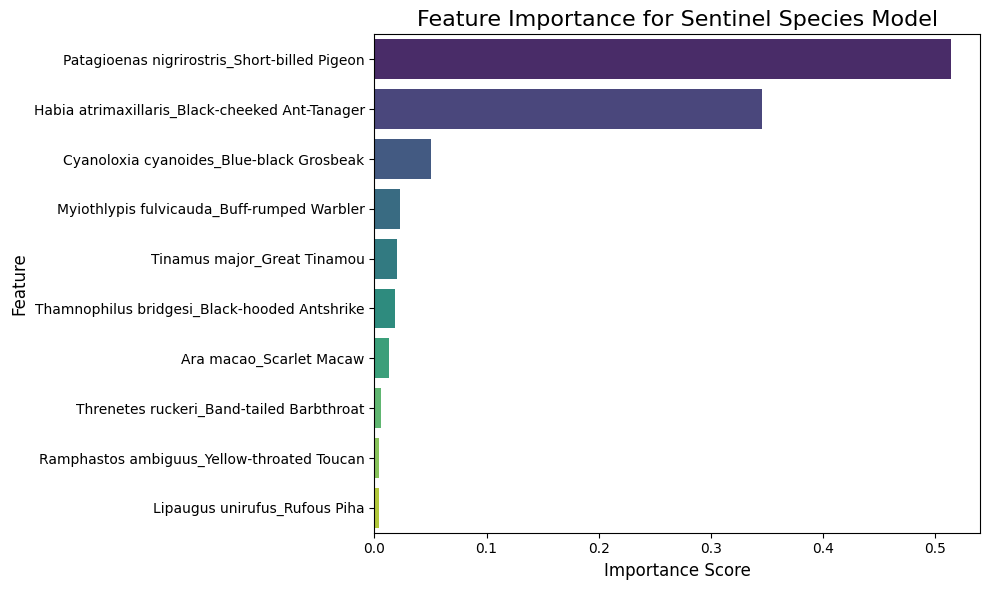

In [ ]:
# Train model with only sentinel species
X_sentinel = df[sentinel_species_cols].copy()
y = df['is_simulation'].copy()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sentinel, y, test_size=0.2, random_state=42, stratify=y
)

xgb_sentinel = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_sentinel.fit(X_train_s, y_train_s)
y_pred_proba_sentinel = xgb_sentinel.predict_proba(X_test_s)[:, 1]

print(f"Sentinel species model ROC-AUC: {roc_auc_score(y_test_s, y_pred_proba_sentinel):.4f}")

# Find best threshold
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_s = 0
best_thresh_s = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_sentinel >= thresh).astype(int)
    f1 = f1_score(y_test_s, y_pred)
    if f1 > best_f1_s:
        best_f1_s = f1
        best_thresh_s = thresh

y_pred_sentinel = (y_pred_proba_sentinel >= best_thresh_s).astype(int)

print(f"Best threshold: {best_thresh_s:.2f}, F1: {best_f1_s:.3f}")
print(classification_report(y_test_s, y_pred_sentinel))

print(f"\nFeature importance:")

for i, feature in enumerate(sentinel_features):
    print(f"{feature}: {xgb_sentinel.feature_importances_[i]:.3f}")

plot_feature_importance(
    model=xgb_sentinel,
    feature_names=X_sentinel.columns,
    title='Feature Importance for Sentinel Species Model'
)

Combined model ROC-AUC: 0.9426
              precision    recall  f1-score   support

           0       0.99      0.90      0.95     91156
           1       0.18      0.80      0.29      2342

    accuracy                           0.90     93498
   macro avg       0.59      0.85      0.62     93498
weighted avg       0.97      0.90      0.93     93498


Feature importance:
                                           feature  importance
7                                           MFCC_9    0.400487
6                                           MFCC_8    0.081941
0                              Spectral RMS Energy    0.060206
4                           Spectral Rolloff (85%)    0.059043
8                                          MFCC_12    0.058473
3                               Spectral Bandwidth    0.051774
1                                Spectral Contrast    0.043035
9                                          MFCC_13    0.042624
14    Patagioenas nigrirostris_Short-billed Pigeon    

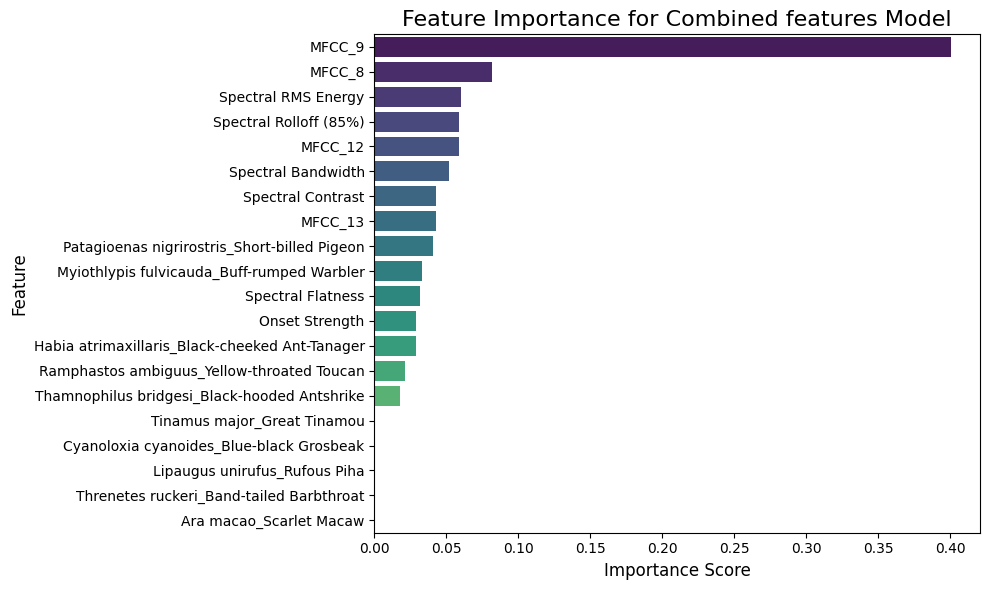

In [ ]:


X_combined = df[combined_features].copy()
y = df['is_simulation'].copy()

X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# Scale only acoustic features
scaler_cb = StandardScaler()
X_train_cb_scaled = X_train_cb.copy()
X_test_cb_scaled = X_test_cb.copy()

X_train_cb_scaled[core_features] = scaler_cb.fit_transform(X_train_cb[core_features])
X_test_cb_scaled[core_features] = scaler_cb.transform(X_test_cb[core_features])

# Use XGBoost
xgb_cb = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_cb.fit(X_train_cb_scaled, y_train_cb)
y_pred_cb = xgb_cb.predict(X_test_cb_scaled)
y_pred_proba_cb = xgb_cb.predict_proba(X_test_cb_scaled)[:, 1]

print(f"Combined model ROC-AUC: {roc_auc_score(y_test_cb, y_pred_proba_cb):.4f}")
print(classification_report(y_test_cb, y_pred_cb))

# Check feature importance
importance = pd.DataFrame({
    'feature': combined_features,
    'importance': xgb_cb.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature importance:")
print(importance)

plot_feature_importance(
    model=xgb_cb,
    feature_names=combined_features,
    title='Feature Importance for Combined features Model'
)

In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    y_pred = (y_pred_proba_cb >= thresh).astype(int)
    precision = precision_score(y_test_cb, y_pred)
    recall = recall_score(y_test_cb, y_pred)
    f1 = f1_score(y_test_cb, y_pred)
    results.append([thresh, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])

# Find best F1 threshold
best_f1_row = results_df.loc[results_df['F1'].idxmax()]
print(f"Best F1 threshold: {best_f1_row['Threshold']:.2f}")
print(f"Precision: {best_f1_row['Precision']:.3f}, Recall: {best_f1_row['Recall']:.3f}, F1: {best_f1_row['F1']:.3f}")

# Show top 5 thresholds
print("\nTop 5 thresholds by F1:")
print(results_df.nlargest(5, 'F1').round(3))

best_thresh = best_f1_row['Threshold']
y_pred_best = (y_pred_proba_cb >= best_thresh).astype(int)

print(f"\nResults with threshold {best_thresh:.2f}:")
print(classification_report(y_test_cb, y_pred_best))

Best F1 threshold: 0.70
Precision: 0.313, Recall: 0.518, F1: 0.390

Top 5 thresholds by F1:
    Threshold  Precision  Recall     F1
12       0.70      0.313   0.518  0.390
13       0.75      0.340   0.449  0.387
11       0.65      0.285   0.589  0.385
14       0.80      0.384   0.368  0.376
10       0.60      0.252   0.666  0.366

Results with threshold 0.70:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     91156
           1       0.31      0.52      0.39      2342

    accuracy                           0.96     93498
   macro avg       0.65      0.74      0.68     93498
weighted avg       0.97      0.96      0.96     93498



Feature importance (all expanded features):
                                           feature  importance
7                                           MFCC_9    0.227478
21                                        hour_cos    0.193682
20                                        hour_sin    0.102113
25                                     Temperature    0.099048
27                                       Windspeed    0.072156
26                                        Humidity    0.043828
8                                          MFCC_12    0.031485
4                           Spectral Rolloff (85%)    0.028331
0                              Spectral RMS Energy    0.027631
2                                Spectral Flatness    0.022950
23                               Volume_Wind_Ratio    0.021876
3                               Spectral Bandwidth    0.020153
9                                          MFCC_13    0.019487
6                                           MFCC_8    0.018233
5          

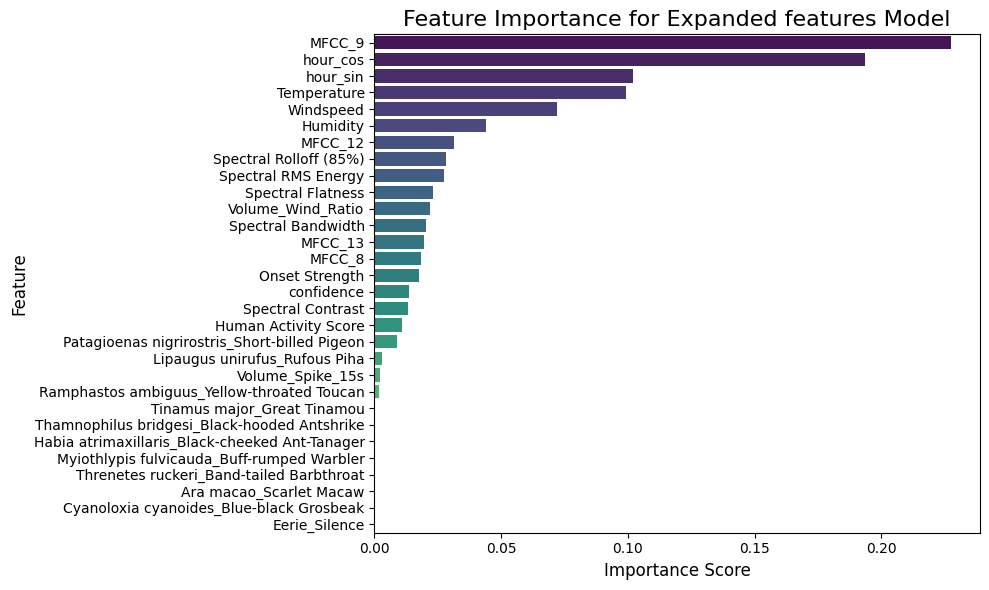

In [ ]:
import ast

# Use expanded features to find overall importance
X_expanded = df[expanded_features].copy()
y = df['is_simulation'].copy()

# Fix the 'confidence' column which contains string lists like '[]'
def parse_confidence(val):
    if pd.isna(val): return 0.0
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return 0.0
    if isinstance(val, list):
        return float(max(val)) if len(val) > 0 else 0.0
    try:
        return float(val)
    except:
        return 0.0

if 'confidence' in X_expanded.columns:
    X_expanded['confidence'] = X_expanded['confidence'].apply(parse_confidence)

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_expanded, y, test_size=0.2, random_state=42, stratify=y
)

scaler_exp = StandardScaler()
# Update the binary columns to exclude from scaling
binary_cols = sentinel_species_cols + ['Eerie_Silence']
features_to_scale = [f for f in expanded_features if f not in binary_cols]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale] = scaler_exp.fit_transform(X_train_exp[features_to_scale])
X_test_exp_scaled[features_to_scale] = scaler_exp.transform(X_test_exp[features_to_scale])

xgb_exp = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_exp.fit(X_train_exp_scaled, y_train_exp)

importance_exp = pd.DataFrame({
    'feature': expanded_features,
    'importance': xgb_exp.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature importance (all expanded features):")
print(importance_exp)

plot_feature_importance(
    model=xgb_exp,
    feature_names=expanded_features,
    title='Feature Importance for Expanded features Model'
)

In [ ]:
# Use sentinel species + top features
custom_features = sentinel_species_cols + [
    'Windspeed', 'Temperature', 'hour_sin', 'hour_cos',
    'Spectral RMS Energy', 'Humidity', 'MFCC_12'
]

print("Custom features:", custom_features)

X_custom = df[custom_features].copy()
y = df['is_simulation'].copy()

X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom, y, test_size=0.2, random_state=42, stratify=y
)

scaler_custom = StandardScaler()
# Exclude boolean sentinel columns from scaling
features_to_scale_custom = [f for f in custom_features if f not in sentinel_species_cols]

X_train_custom_scaled = X_train_custom.copy()
X_test_custom_scaled = X_test_custom.copy()
X_train_custom_scaled[features_to_scale_custom] = scaler_custom.fit_transform(X_train_custom[features_to_scale_custom])
X_test_custom_scaled[features_to_scale_custom] = scaler_custom.transform(X_test_custom[features_to_scale_custom])

xgb_custom = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=20,
    eval_metric='logloss'
)

xgb_custom.fit(X_train_custom_scaled, y_train_custom)
y_pred_proba_custom = xgb_custom.predict_proba(X_test_custom_scaled)[:, 1]

print(f"\nCustom model ROC-AUC: {roc_auc_score(y_test_custom, y_pred_proba_custom):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_custom = 0
best_thresh_custom = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_custom >= thresh).astype(int)
    f1 = f1_score(y_test_custom, y_pred)
    if f1 > best_f1_custom:
        best_f1_custom = f1
        best_thresh_custom = thresh

y_pred_custom = (y_pred_proba_custom >= best_thresh_custom).astype(int)
print(f"Best threshold: {best_thresh_custom:.2f}, F1: {best_f1_custom:.3f}")
print(classification_report(y_test_custom, y_pred_custom))

Custom features: ['Myiothlypis fulvicauda_Buff-rumped Warbler', 'Habia atrimaxillaris_Black-cheeked Ant-Tanager', 'Thamnophilus bridgesi_Black-hooded Antshrike', 'Tinamus major_Great Tinamou', 'Patagioenas nigrirostris_Short-billed Pigeon', 'Ramphastos ambiguus_Yellow-throated Toucan', 'Cyanoloxia cyanoides_Blue-black Grosbeak', 'Lipaugus unirufus_Rufous Piha', 'Threnetes ruckeri_Band-tailed Barbthroat', 'Ara macao_Scarlet Macaw', 'Windspeed', 'Temperature', 'hour_sin', 'hour_cos', 'Spectral RMS Energy', 'Humidity', 'MFCC_12']

Custom model ROC-AUC: 0.9804
Best threshold: 0.80, F1: 0.524
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     91156
           1       0.39      0.79      0.52      2342

    accuracy                           0.96     93498
   macro avg       0.69      0.88      0.75     93498
weighted avg       0.98      0.96      0.97     93498



In [ ]:
# Filter data to only include sentinel species detections
sentinel_mask = (df[sentinel_species_cols] == 1).any(axis=1)
df_sentinel_only = df[sentinel_mask].copy()

print(f"Original dataset: {len(df)} rows")
print(f"Sentinel species only: {len(df_sentinel_only)} rows")
print(f"Reduction: {(1 - len(df_sentinel_only)/len(df))*100:.1f}%")

print(f"\nSimulation distribution:")
print(f"Original - Simulations: {df['is_simulation'].sum()}, Total: {len(df)}")
print(f"Filtered - Simulations: {df_sentinel_only['is_simulation'].sum()}, Total: {len(df_sentinel_only)}")

sim_rate_original = df['is_simulation'].mean()
sim_rate_filtered = df_sentinel_only['is_simulation'].mean()
print(f"\nSimulation rate:")
print(f"Original: {sim_rate_original:.4f} ({sim_rate_original*100:.2f}%)")
print(f"Filtered: {sim_rate_filtered:.4f} ({sim_rate_filtered*100:.2f}%)")
print(f"Rate increase: {sim_rate_filtered/sim_rate_original:.2f}x")

Original dataset: 467488 rows
Sentinel species only: 19286 rows
Reduction: 95.9%

Simulation distribution:
Original - Simulations: 11708, Total: 467488
Filtered - Simulations: 427, Total: 19286

Simulation rate:
Original: 0.0250 (2.50%)
Filtered: 0.0221 (2.21%)
Rate increase: 0.88x


#### Filtered XGBoosting

Filtered train set: 15428 rows, Simulations: 342
Filtered test set: 3858 rows, Simulations: 85
New scale_pos_weight: 44.1

Filtered model ROC-AUC: 0.9925
Best threshold: 0.85, F1: 0.678
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3773
           1       0.54      0.91      0.68        85

    accuracy                           0.98      3858
   macro avg       0.77      0.94      0.83      3858
weighted avg       0.99      0.98      0.98      3858



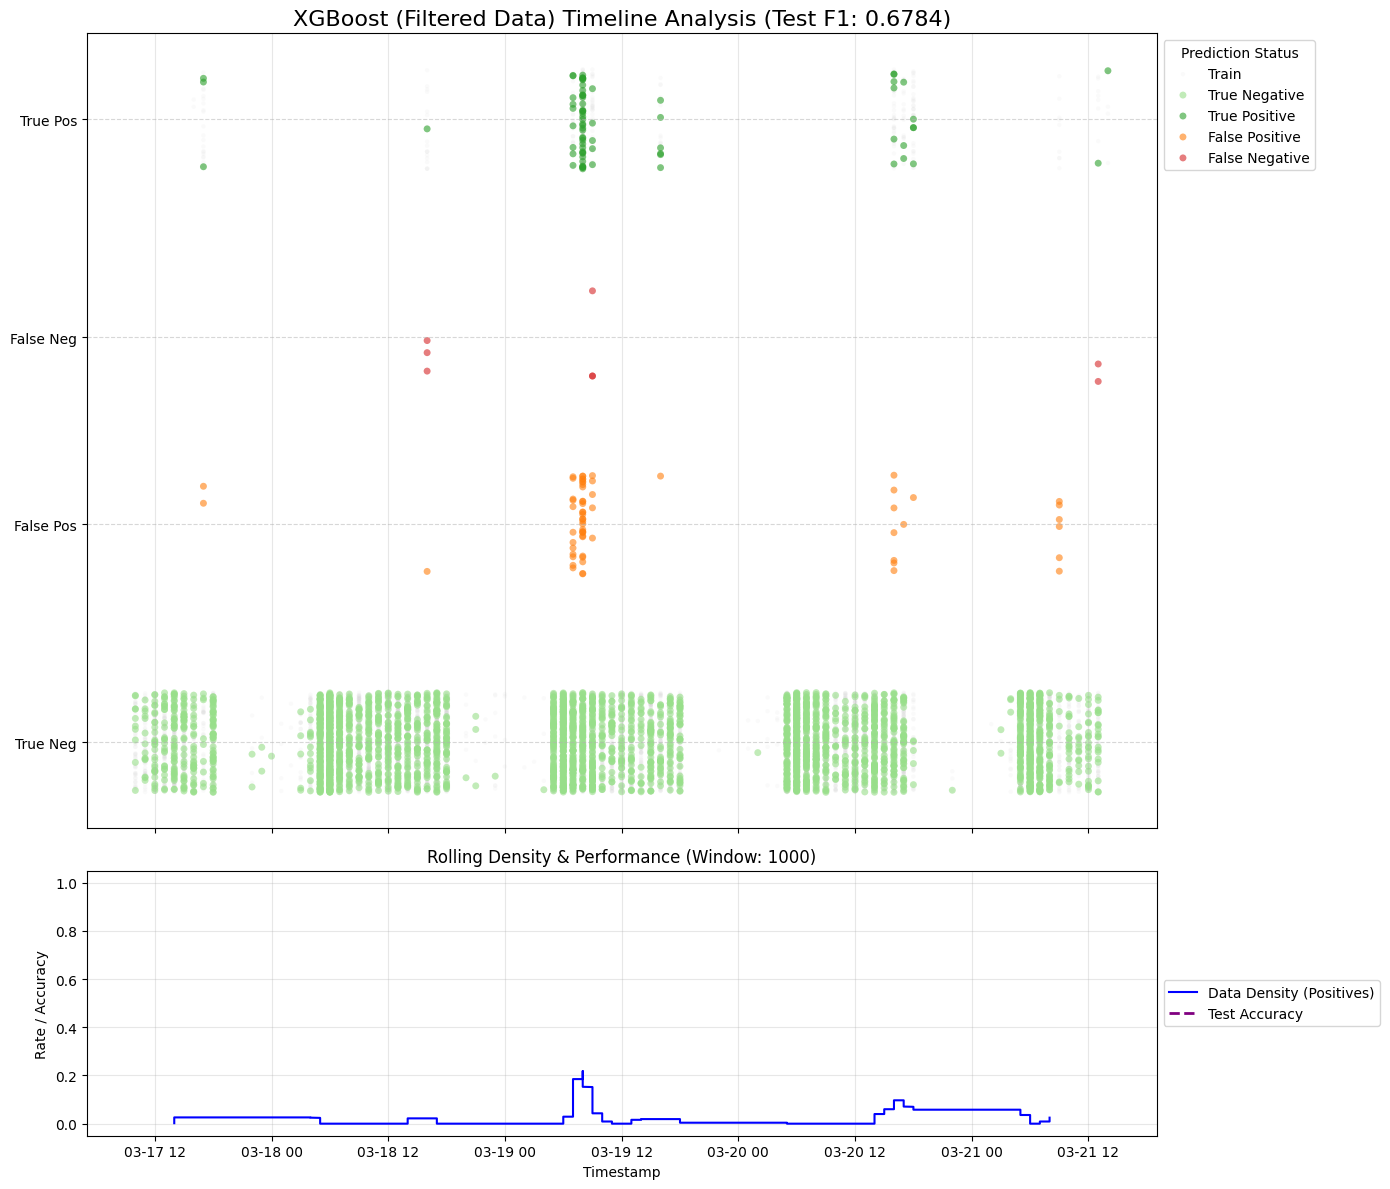

In [ ]:


X_filtered = df_sentinel_only[custom_features].copy()
y_filtered = df_sentinel_only['is_simulation'].copy()

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"Filtered train set: {len(X_train_f)} rows, Simulations: {y_train_f.sum()}")
print(f"Filtered test set: {len(X_test_f)} rows, Simulations: {y_test_f.sum()}")

scaler_f = StandardScaler()
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

X_train_f_scaled = X_train_f.copy()
X_test_f_scaled = X_test_f.copy()
X_train_f_scaled[features_to_scale] = scaler_f.fit_transform(X_train_f[features_to_scale])
X_test_f_scaled[features_to_scale] = scaler_f.transform(X_test_f[features_to_scale])
pos_weight = (y_train_f == 0).sum() / y_train_f.sum()
print(f"New scale_pos_weight: {pos_weight:.1f}")

xgb_filtered = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    eval_metric='logloss'
)

xgb_filtered.fit(X_train_f_scaled, y_train_f)
y_pred_proba_f = xgb_filtered.predict_proba(X_test_f_scaled)[:, 1]

print(f"\nFiltered model ROC-AUC: {roc_auc_score(y_test_f, y_pred_proba_f):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_f = 0
best_thresh_f = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_f >= thresh).astype(int)
    f1 = f1_score(y_test_f, y_pred)
    if f1 > best_f1_f:
        best_f1_f = f1
        best_thresh_f = thresh

y_pred_f = (y_pred_proba_f >= best_thresh_f).astype(int)
print(f"Best threshold: {best_thresh_f:.2f}, F1: {best_f1_f:.3f}")
print(classification_report(y_test_f, y_pred_f))

visualize_model_performance(
    df=df_sentinel_only,              # The original dataframe (for timestamps)
    y_train=y_train_f,    # The training labels with indices
    y_test=y_test_f,      # The test labels with indices
    y_pred=y_pred,  # The predictions you just generated
    model_name="XGBoost (Filtered Data)"
)

Filtering data to sentinel species only...
Original dataset: 467488 rows
Filtered (sentinel-only) dataset: 19286 rows

Processing XGBoost (Filtered) for: Audio_Moth_1
Data Prepared: Train size: 3432, Test size: 858
Train sim rate: 4.49%, Test sim rate: 4.55%
Using scale_pos_weight: 21.3

Filtered model ROC-AUC: 0.9895
Best threshold: 0.55, F1: 0.763
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       819
           1       0.64      0.95      0.76        39

    accuracy                           0.97       858
   macro avg       0.82      0.96      0.87       858
weighted avg       0.98      0.97      0.98       858

--- Calculating Permutation Importance for Audio_Moth_1 ---
Calculating permutation importance...


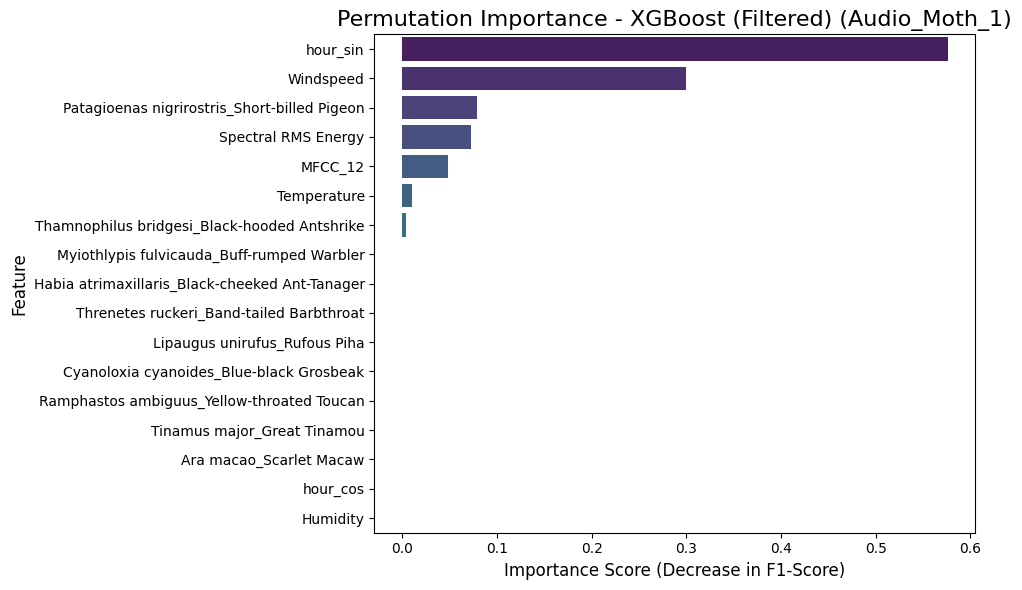


Processing XGBoost (Filtered) for: Audio_Moth_2
No data found for Audio_Moth_2.
Skipping Audio_Moth_2 due to insufficient data.

Processing XGBoost (Filtered) for: Audio_Moth_3
No data found for Audio_Moth_3.
Skipping Audio_Moth_3 due to insufficient data.

Processing XGBoost (Filtered) for: Audio_Moth_4
Data Prepared: Train size: 2112, Test size: 529
Train sim rate: 0.76%, Test sim rate: 0.76%
Using scale_pos_weight: 131.0

Filtered model ROC-AUC: 0.9910
Best threshold: 0.85, F1: 0.750
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       525
           1       0.75      0.75      0.75         4

    accuracy                           1.00       529
   macro avg       0.87      0.87      0.87       529
weighted avg       1.00      1.00      1.00       529

--- Calculating Permutation Importance for Audio_Moth_4 ---
Calculating permutation importance...


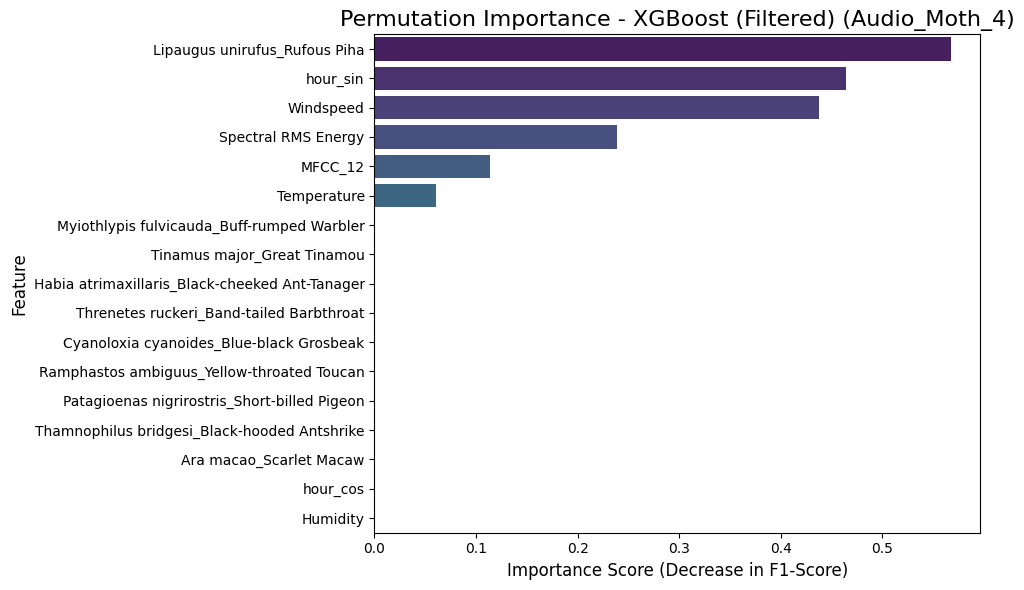


Processing XGBoost (Filtered) for: Audio_Moth_5
Data Prepared: Train size: 3904, Test size: 976
Train sim rate: 1.61%, Test sim rate: 1.64%
Using scale_pos_weight: 61.0

Filtered model ROC-AUC: 0.9999
Best threshold: 0.80, F1: 0.938
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       960
           1       0.94      0.94      0.94        16

    accuracy                           1.00       976
   macro avg       0.97      0.97      0.97       976
weighted avg       1.00      1.00      1.00       976

--- Calculating Permutation Importance for Audio_Moth_5 ---
Calculating permutation importance...


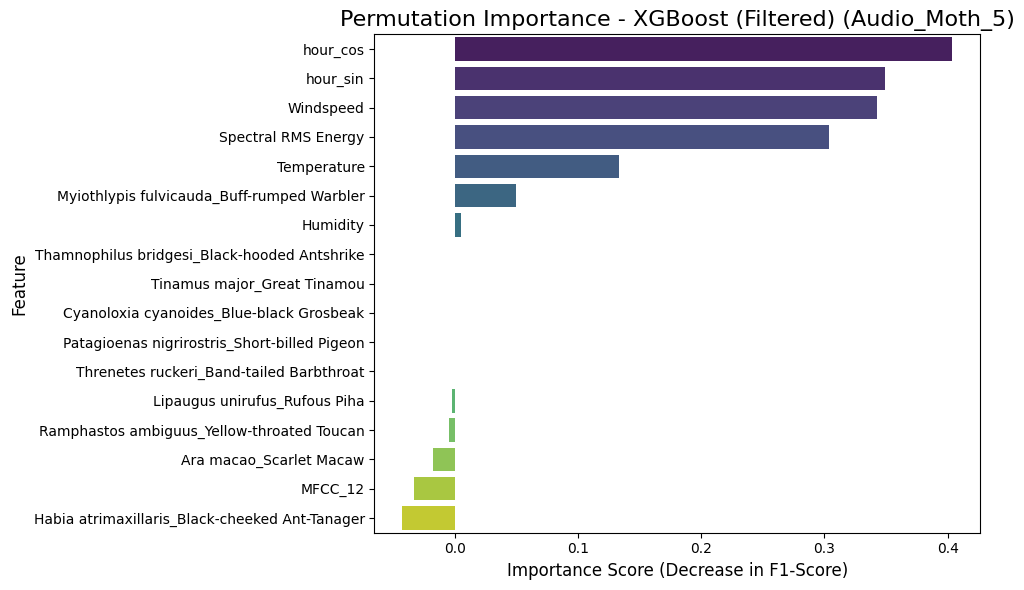


Processing XGBoost (Filtered) for: Audio_Moth_6
Data Prepared: Train size: 5980, Test size: 1495
Train sim rate: 1.81%, Test sim rate: 1.81%
Using scale_pos_weight: 54.4

Filtered model ROC-AUC: 0.9958
Best threshold: 0.50, F1: 0.693
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1468
           1       0.54      0.96      0.69        27

    accuracy                           0.98      1495
   macro avg       0.77      0.97      0.84      1495
weighted avg       0.99      0.98      0.99      1495

--- Calculating Permutation Importance for Audio_Moth_6 ---
Calculating permutation importance...


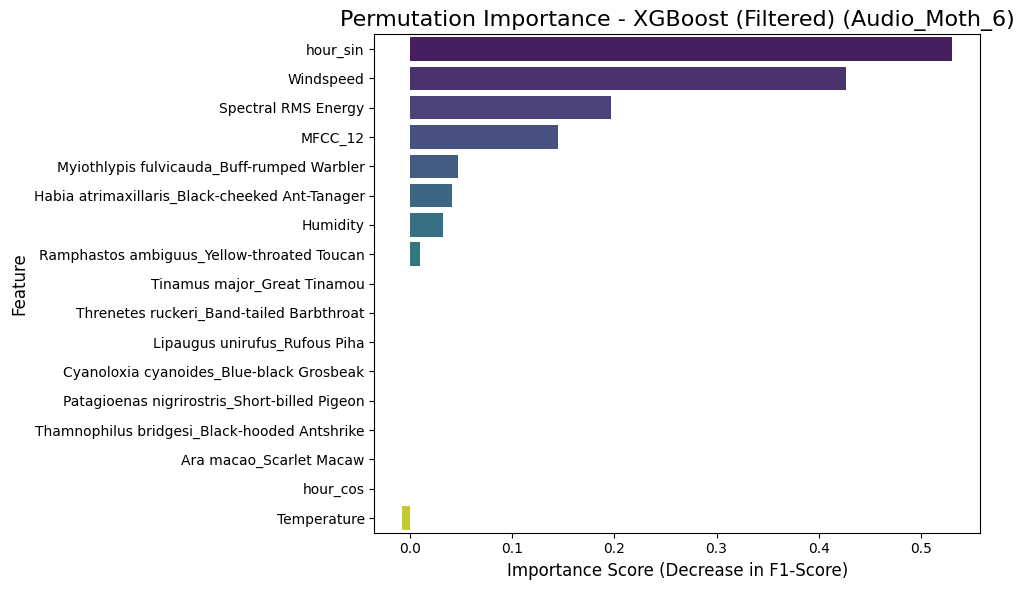


FINAL SUMMARY FOR XGBOOST (FILTERED) ACROSS ALL DEVICES
         device               model  f1_score  roc_auc  precision  recall  \
0  Audio_Moth_1  XGBoost (Filtered)     0.763    0.990      0.638   0.949   
1  Audio_Moth_2  XGBoost (Filtered)       NaN      NaN        NaN     NaN   
2  Audio_Moth_3  XGBoost (Filtered)       NaN      NaN        NaN     NaN   
3  Audio_Moth_4  XGBoost (Filtered)     0.750    0.991      0.750   0.750   
4  Audio_Moth_5  XGBoost (Filtered)     0.938    1.000      0.938   0.938   
5  Audio_Moth_6  XGBoost (Filtered)     0.693    0.996      0.542   0.963   

   best_threshold  test_sim_rate  
0            0.55          0.045  
1             NaN            NaN  
2             NaN            NaN  
3            0.85          0.008  
4            0.80          0.016  
5            0.50          0.018  


In [ ]:
def get_device_data_custom_scaled(df, device_name, device_col, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Filters, splits, and custom-scales data for a single device.
    This function scales only non-boolean features (not starting with 'is_').
    """
    # Filter for the specific device
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty:
        print(f"No data found for {device_name}.")
        return None, None, None, None

    X_device = device_df[feature_cols]
    y_device = device_df[target_col]

    if X_device.shape[0] < 10:
        print(f"Insufficient data for {device_name} (found {X_device.shape[0]} rows).")
        return None, None, None, None

    # Check for stratification
    stratify_param = y_device if y_device.nunique() > 1 else None
    if stratify_param is None:
        print(f"Warning: Only one class present. Splitting without stratification.")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # --- Custom Scaling Logic ---
    features_to_scale = [f for f in feature_cols if not f.startswith('is_')]

    scaler = StandardScaler()

    # Copy to avoid 'SettingWithCopyWarning'
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    # Fit on train and transform both train and test
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

    return best_f1, best_threshold

# --- 3. Initial Data Filtering ---
# (Assuming 'df' is your full, original DataFrame)

print("Filtering data to sentinel species only...")
sentinel_mask = (df[sentinel_species_cols] == 1).any(axis=1)
df_sentinel_only = df[sentinel_mask].copy()
print(f"Original dataset: {len(df)} rows")
print(f"Filtered (sentinel-only) dataset: {len(df_sentinel_only)} rows")

# --- 4. Main Loop to Run XGBoost ---

audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]
DEVICE_COLUMN = 'recorder_id'     # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation' # The column in 'df' with the 0/1 target

all_results = []

for moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"Processing XGBoost (Filtered) for: {moth_name}")
    print("="*80)

    # --- Get Data ---
    # !! We pass df_SENTINEL_ONLY to the function !!
    data_pack = get_device_data_custom_scaled(
        df_sentinel_only, # <-- Using the pre-filtered DataFrame
        moth_name,
        DEVICE_COLUMN,
        custom_features,   # <-- Using your custom feature list
        TARGET_COLUMN,
        test_size=0.2      # <-- Matching your 0.2 test size
    )


    X_train_scaled, X_test_scaled, y_train, y_test = data_pack

    if X_train_scaled is None:
        print(f"Skipping {moth_name} due to insufficient data.")
        all_results.append({
            'device': moth_name, 'model': 'XGBoost (Filtered)', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue

    print(f"Data Prepared: Train size: {len(X_train_scaled)}, Test size: {len(X_test_scaled)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # 2. Check if training data has both classes (0 and 1)
    if y_train.nunique() < 2:
        print(f"Skipping {moth_name}: Training data has only one class (no positive samples).")
        all_results.append({
            'device': moth_name, 'model': 'XGBoost (Filtered)', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue # <-- Skips to the next moth

    # --- Train XGBoost Model ---

    # Calculate scale_pos_weight dynamically for *this device's* training data
    if y_train.sum() > 0:
        pos_weight = (y_train == 0).sum() / y_train.sum()
    else:
        print("Warning: No positive samples in training set. Setting pos_weight=1.")
        pos_weight = 1

    print(f"Using scale_pos_weight: {pos_weight:.1f}")

    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight, # Use the dynamically calculated weight
        eval_metric='logloss'
    )

    xgb_model.fit(X_train_scaled, y_train)
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

    # --- Evaluate ---
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nFiltered model ROC-AUC: {roc_auc:.4f}")

    # Find best threshold
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    print(f"Best threshold: {best_thresh:.2f}, F1: {best_f1:.3f}")

    # Get final predictions and classification report
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)
    print(classification_report(y_test, y_pred_final, zero_division=0))

    # Permutation Feature importance
    print(f"--- Calculating Permutation Importance for {moth_name} ---")
    plot_permutation_importance(
        model=xgb_model,
        X_test=X_test_scaled,
        y_test=y_test,
        feature_names=custom_features, # Use 'custom_features' for this model
        title=f"Permutation Importance - XGBoost (Filtered) ({moth_name})"
    )

    # Store results
    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    all_results.append({
        'device': moth_name,
        'model': 'XGBoost (Filtered)',
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_sim_rate': y_test.mean()
    })

# --- 5. Final Summary ---
print(f"\n" + "="*80)
print("FINAL SUMMARY FOR XGBOOST (FILTERED) ACROSS ALL DEVICES")
print("="*80)

summary_df = pd.DataFrame(all_results)
print(summary_df.round(3))

Filtering data to sentinel species only...
Original dataset: 467488 rows
Filtered (sentinel-only) dataset: 19286 rows

--- Pre-processing data for all devices (from filtered dataset) ---
  -> Stored data for Audio_Moth_1 (Train: 3432, Test: 858)
  -> No/Insufficient data for Audio_Moth_2
  -> No/Insufficient data for Audio_Moth_3
  -> Stored data for Audio_Moth_4 (Train: 2112, Test: 529)
  -> Stored data for Audio_Moth_5 (Train: 3904, Test: 976)
  -> Stored data for Audio_Moth_6 (Train: 5980, Test: 1495)
--- Data pre-processing complete ---

TRAINING Model on: Audio_Moth_1 (XGBoost Filtered)
Using scale_pos_weight: 21.3
--- Testing 'Audio_Moth_1' model on all devices: ---
  -> TESTED on Audio_Moth_1: F1 = 0.763 (P: 0.638, R: 0.949)
  -> Skipping test on Audio_Moth_2: Insufficient test data.
  -> Skipping test on Audio_Moth_3: Insufficient test data.
  -> TESTED on Audio_Moth_4: F1 = 0.000 (P: 0.000, R: 0.000)
  -> TESTED on Audio_Moth_5: F1 = 0.000 (P: 0.000, R: 0.000)
  -> TESTED on A

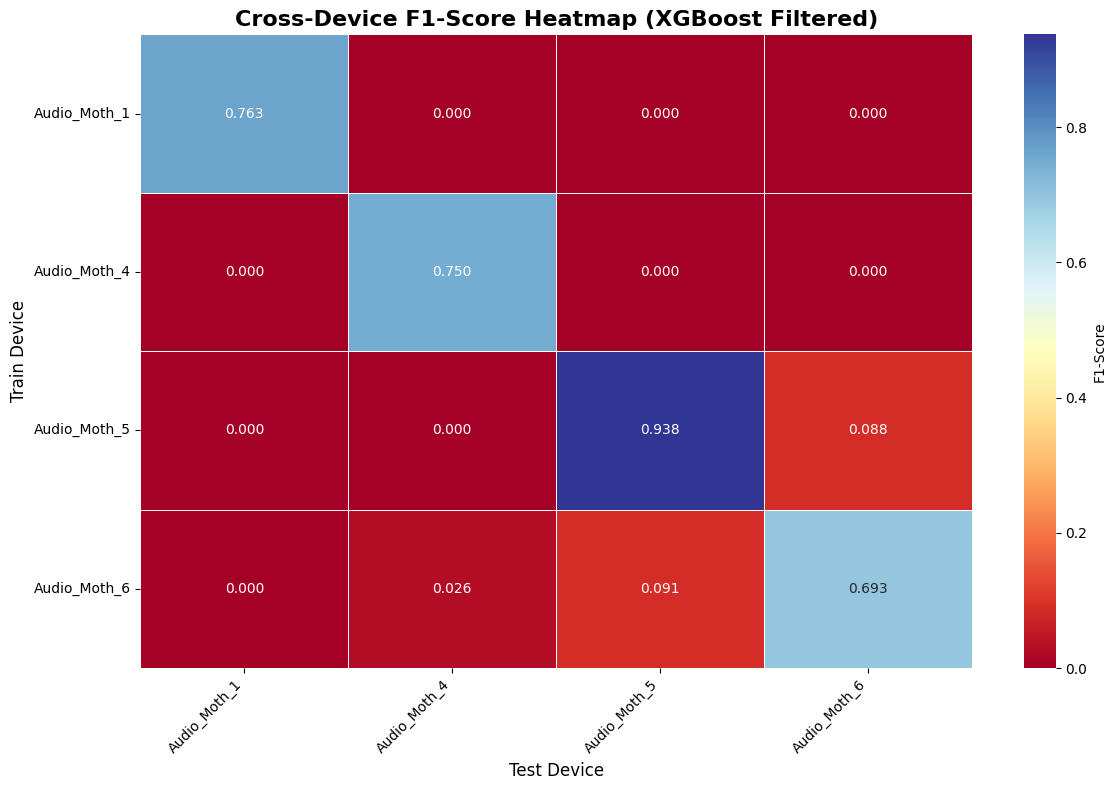

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Your Devices and Features ---
# Update to the corrected feature names including Patrick's features
custom_features = sentinel_species_cols + [
    'Windspeed', 'Temperature', 'hour_sin', 'hour_cos',
    'Spectral RMS Energy', 'Humidity', 'MFCC_12'
]

audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]

DEVICE_COLUMN = 'recorder_id'
FEATURE_COLUMNS = custom_features # <-- Using your custom feature list
TARGET_COLUMN = 'is_simulation'

# --- 2. Helper Functions (From your code) ---

def get_device_data_custom_scaled(df, device_name, device_col, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Filters, splits, and custom-scales data for a single device.
    This function scales only non-boolean features (not starting with 'is_').
    """
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty: return None, None, None, None
    X_device = device_df[feature_cols]
    y_device = device_df[target_col]
    if X_device.shape[0] < 10: return None, None, None, None

    stratify_param = y_device if y_device.nunique() > 1 else None

    # Split the raw (unscaled) data first
    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # --- Custom Scaling Logic ---
    features_to_scale = [f for f in feature_cols if f not in sentinel_species_cols]
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    # Fit on train and transform both train and test
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Initial Data Filtering ---
# (Assuming 'df' is your full, original DataFrame)
print("Filtering data to sentinel species only...")
# Use the correct logic established earlier to filter sentinel species
sentinel_mask = (df[sentinel_species_cols] == 1).any(axis=1)
df_sentinel_only = df[sentinel_mask].copy()
print(f"Original dataset: {len(df)} rows")
print(f"Filtered (sentinel-only) dataset: {len(df_sentinel_only)} rows")


# --- 4. Pre-process and Cache Data for All Devices ---
data_bundles = {}
print("\n--- Pre-processing data for all devices (from filtered dataset) ---")
for moth_name in audio_moths:
    data_pack = get_device_data_custom_scaled(
        df_sentinel_only, # <-- Using the pre-filtered DataFrame
        moth_name,
        DEVICE_COLUMN,
        FEATURE_COLUMNS,
        TARGET_COLUMN,
        test_size=0.2    # <-- Matching your 0.2 test size
    )

    data_bundles[moth_name] = data_pack

    if data_pack[0] is not None:
        print(f"  -> Stored data for {moth_name} (Train: {len(data_pack[0])}, Test: {len(data_pack[1])})")
    else:
        print(f"  -> No/Insufficient data for {moth_name}")
print("--- Data pre-processing complete ---")


# --- 5. Main Nested Loop for Cross-Device Testing ---

all_cross_device_results = []

# --- Outer Loop: TRAIN on this device ---
for train_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"TRAINING Model on: {train_moth_name} (XGBoost Filtered)")
    print("="*80)

    # Get the training data for this moth
    X_train_scaled, _, y_train, _ = data_bundles[train_moth_name]

    # --- Check if training is possible ---
    if X_train_scaled is None:
        print(f"Skipping training for {train_moth_name}: Insufficient data.")
        continue

    if y_train.nunique() < 2:
        print(f"Skipping training for {train_moth_name}: Training data has only one class.")
        continue

    # --- Calculate dynamic scale_pos_weight ---
    if y_train.sum() > 0:
        pos_weight = (y_train == 0).sum() / y_train.sum()
    else:
        pos_weight = 1 # Should be unreachable due to check above, but safe
    print(f"Using scale_pos_weight: {pos_weight:.1f}")

    # --- Train the XGBoost Model ---
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight, # Use the dynamically calculated weight
        eval_metric='logloss'
    )
    xgb_model.fit(X_train_scaled, y_train)

    # --- Inner Loop: TEST on this device ---
    print(f"--- Testing '{train_moth_name}' model on all devices: ---")
    for test_moth_name in audio_moths:

        # Get the TEST data for the inner moth
        _, X_test_scaled, _, y_test = data_bundles[test_moth_name]

        # --- Check if testing is possible ---
        if X_test_scaled is None or y_test is None:
            print(f"  -> Skipping test on {test_moth_name}: Insufficient test data.")
            continue

        if y_test.nunique() < 2:
            print(f"  -> Skipping test on {test_moth_name}: Test data has only one class.")
            continue

        # --- Test and Evaluate ---
        y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

        best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
        y_pred_final = (y_pred_proba >= best_thresh).astype(int)

        sim_precision = precision_score(y_test, y_pred_final, zero_division=0)
        sim_recall = recall_score(y_test, y_pred_final, zero_division=0)

        print(f"  -> TESTED on {test_moth_name}: F1 = {best_f1:.3f} (P: {sim_precision:.3f}, R: {sim_recall:.3f})")

        all_cross_device_results.append({
            'train_device': train_moth_name,
            'test_device': test_moth_name,
            'f1_score': best_f1,
            'precision': sim_precision,
            'recall': sim_recall
        })

# --- 6. Final Summary ---
print(f"\n" + "="*80)
print("SUMMARY OF CROSS-DEVICE VALIDATION (XGBoost Filtered)")
print("="*80)

results_df_xgb = pd.DataFrame(all_cross_device_results)

if results_df_xgb.empty:
    print("No models were successfully trained and evaluated. Heatmap cannot be generated.")
else:
    # A pivot table is the best way to view this
    print("--- F1-Score Heatmap (Train device = rows, Test device = columns) ---")
    f1_pivot_xgb = results_df_xgb.pivot(
        index='train_device',
        columns='test_device',
        values='f1_score'
    )
    print(f1_pivot_xgb.round(3))

    # --- 7. Generate Heatmap Visualization ---
    print("\n--- Generating Heatmap ---")
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        f1_pivot_xgb,
        annot=True,        # Show the F1-score numbers
        fmt=".3f",         # Format to 3 decimal places
        cmap="RdYlBu",     # Color map: Red (high/good) to Blue (low/bad)
        linewidths=.5,
        cbar_kws={'label': 'F1-Score'}
    )

    plt.title('Cross-Device F1-Score Heatmap (XGBoost Filtered)', fontsize=16, weight='bold')
    plt.xlabel('Test Device', fontsize=12)
    plt.ylabel('Train Device', fontsize=12)
    plt.yticks(rotation=0)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('cross_device_f1_heatmap_xgb.png')
    plt.show()

#### Cross validating original model using sentinel species data for the whole dataset

In [ ]:

# --- 1. Prepare Full Dataset ---

print(f"Using {len(custom_features)} features: {custom_features}")
X_full = df_sentinel_only[custom_features].copy()
y_full = df_sentinel_only['is_simulation'].copy()

# Identify which features to scale (all except the 'is_' boolean flags)
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

# --- 2. Set up Cross-Validation ---
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_results = []
print(f"\n--- Starting {n_splits}-Fold Stratified Cross-Validation ---")

# --- 3. Run the Cross-Validation Loop ---
for fold, (train_index, val_index) in enumerate(skf.split(X_full, y_full)):
    print(f"\n" + "="*60)
    print(f"Processing Fold {fold + 1} / {n_splits}")
    print("="*60)

    # Split data for this fold using the indices
    # We use .iloc to select rows by integer index
    X_train, X_val = X_full.iloc[train_index], X_full.iloc[val_index]
    y_train, y_val = y_full.iloc[train_index], y_full.iloc[val_index]

    # --- Scale Data (INSIDE the loop) ---
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()

    # Fit scaler ONLY on X_train and transform both
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_val_scaled[features_to_scale] = scaler.transform(X_val[features_to_scale])

    # --- Calculate pos_weight (INSIDE the loop) ---
    if y_train.sum() > 0:
        pos_weight = (y_train == 0).sum() / y_train.sum()
    else:
        pos_weight = 1 # Fallback in case a fold has no positive samples

    print(f"Train size: {len(y_train)}, Val size: {len(y_val)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Val sim rate: {y_val.mean():.2%}")
    print(f"New scale_pos_weight: {pos_weight:.1f}")

    # --- Define and Train Model ---
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        eval_metric='logloss'
    )

    xgb_model.fit(X_train_scaled, y_train)

    # --- Evaluate on Validation Set ---
    y_pred_proba = xgb_model.predict_proba(X_val_scaled)[:, 1]

    roc_auc = roc_auc_score(y_val, y_pred_proba)
    print(f"\nFold {fold+1} ROC-AUC: {roc_auc:.4f}")

    # --- Find Best Threshold (for this fold) ---
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1 = 0
    best_thresh = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    print(f"Fold {fold+1} Best threshold: {best_thresh:.2f}, Best F1: {best_f1:.3f}")

    # Get final metrics for this fold
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)
    precision = precision_score(y_val, y_pred_final, zero_division=0)
    recall = recall_score(y_val, y_pred_final, zero_division=0)

    # Store results
    fold_results.append({
        'fold': fold + 1,
        'roc_auc': roc_auc,
        'f1_score': best_f1,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh
    })

# --- 4. Final Summary ---
print(f"\n" + "="*60)
print("Cross-Validation Summary (All Folds)")
print("="*60)

results_df = pd.DataFrame(fold_results)
print(results_df.round(4))

print(f"\n" + "="*60)
print("Average Metrics Across All 5 Folds")
print("="*60)
print(results_df.mean().drop('fold').round(4))

Using 17 features: ['Myiothlypis fulvicauda_Buff-rumped Warbler', 'Habia atrimaxillaris_Black-cheeked Ant-Tanager', 'Thamnophilus bridgesi_Black-hooded Antshrike', 'Tinamus major_Great Tinamou', 'Patagioenas nigrirostris_Short-billed Pigeon', 'Ramphastos ambiguus_Yellow-throated Toucan', 'Cyanoloxia cyanoides_Blue-black Grosbeak', 'Lipaugus unirufus_Rufous Piha', 'Threnetes ruckeri_Band-tailed Barbthroat', 'Ara macao_Scarlet Macaw', 'Windspeed', 'Temperature', 'hour_sin', 'hour_cos', 'Spectral RMS Energy', 'Humidity', 'MFCC_12']

--- Starting 5-Fold Stratified Cross-Validation ---

Processing Fold 1 / 5
Train size: 15428, Val size: 3858
Train sim rate: 2.21%, Val sim rate: 2.23%
New scale_pos_weight: 44.2

Fold 1 ROC-AUC: 0.9922
Fold 1 Best threshold: 0.85, Best F1: 0.676

Processing Fold 2 / 5
Train size: 15429, Val size: 3857
Train sim rate: 2.22%, Val sim rate: 2.20%
New scale_pos_weight: 44.1

Fold 2 ROC-AUC: 0.9887
Fold 2 Best threshold: 0.85, Best F1: 0.663

Processing Fold 3 / 5

#### Per-device validation

In [ ]:
# --- 1. Define Features and Device Info ---

# (Make sure these lists and columns are defined)

DEVICE_COLUMN = 'recorder_id' # The column in 'df_sentinel_only' with the moth names

# --- 2. Prepare Data (Your Original Code) ---
X_filtered = df_sentinel_only[custom_features].copy()
y_filtered = df_sentinel_only['is_simulation'].copy()

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print(f"Filtered train set: {len(X_train_f)} rows, Simulations: {y_train_f.sum()}")
print(f"Filtered test set: {len(X_test_f)} rows, Simulations: {y_test_f.sum()}")

# --- 3. (NEW) Get a DataFrame of the Test Set ---
# We use the index from X_test_f to get the original rows from df_sentinel_only.
# This df_test will have the device ID, true label, and features.
df_test = df_sentinel_only.loc[X_test_f.index].copy()

# --- 4. Scale Data (Your Original Code) ---
scaler_f = StandardScaler()
features_to_scale = [f for f in custom_features if not f.startswith('is_')]

X_train_f_scaled = X_train_f.copy()
X_test_f_scaled = X_test_f.copy()
X_train_f_scaled[features_to_scale] = scaler_f.fit_transform(X_train_f[features_to_scale])
X_test_f_scaled[features_to_scale] = scaler_f.transform(X_test_f[features_to_scale])

# --- 5. Train XGBoost (Your Original Code) ---
if y_train_f.sum() > 0:
    pos_weight = (y_train_f == 0).sum() / y_train_f.sum()
else:
    pos_weight = 1

print(f"New scale_pos_weight: {pos_weight:.1f}")

xgb_filtered = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=pos_weight,
    eval_metric='logloss'
)

print("\n--- Training XGBoost on all devices (filtered data) ---")
xgb_filtered.fit(X_train_f_scaled, y_train_f)

# --- 6. Evaluate on ALL Test Data (Your Original Code) ---
y_pred_proba_f = xgb_filtered.predict_proba(X_test_f_scaled)[:, 1]

print(f"\nFiltered model ROC-AUC (Overall): {roc_auc_score(y_test_f, y_pred_proba_f):.4f}")

# Find best threshold (based on overall test set)
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_f = 0
best_thresh_f = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_f >= thresh).astype(int)
    f1 = f1_score(y_test_f, y_pred, zero_division=0)
    if f1 > best_f1_f:
        best_f1_f = f1
        best_thresh_f = thresh

y_pred_f = (y_pred_proba_f >= best_thresh_f).astype(int)
print(f"Best threshold (Overall): {best_thresh_f:.2f}, F1: {best_f1_f:.3f}")
print("\n--- Overall Test Set Performance (All Devices) ---")
print(classification_report(y_test_f, y_pred_f, zero_division=0))


# --- 7. (NEW) Per-Device Evaluation Loop ---
print(f"\n" + "="*80)
print("PER-DEVICE PERFORMANCE BREAKDOWN (ON TEST SET)")
print("="*80)

# Add the final predictions to our test DataFrame
# y_pred_f is a numpy array in the same order as df_test
df_test['y_pred_final'] = y_pred_f

per_device_results = []

for moth_name in audio_moths:
    # Filter the test set for *only* this moth's data
    moth_test_df = df_test[df_test[DEVICE_COLUMN] == moth_name]

    if moth_test_df.empty:
        print(f"\n--- {moth_name} ---")
        print("No test data available for this device.")
        continue

    # Get the true labels and predicted labels for this device
    y_true_device = moth_test_df['is_simulation']
    y_pred_device = moth_test_df['y_pred_final']

    # Calculate metrics
    f1 = f1_score(y_true_device, y_pred_device, zero_division=0)
    precision = precision_score(y_true_device, y_pred_device, zero_division=0)
    recall = recall_score(y_true_device, y_pred_device, zero_division=0)

    print(f"\n--- {moth_name} (Test Samples: {len(y_true_device)}) ---")
    print(f"F1: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

    per_device_results.append({
        'device': moth_name,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'test_samples': len(y_true_device)
    })

# --- 8. (NEW) Final Summary Table ---
print(f"\n" + "="*80)
print("Per-Device Performance Summary")
print("="*80)
summary_df = pd.DataFrame(per_device_results)
print(summary_df.round(3))

Filtered train set: 15428 rows, Simulations: 342
Filtered test set: 3858 rows, Simulations: 85
New scale_pos_weight: 44.1

--- Training XGBoost on all devices (filtered data) ---

Filtered model ROC-AUC (Overall): 0.9925
Best threshold (Overall): 0.85, F1: 0.678

--- Overall Test Set Performance (All Devices) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3773
           1       0.54      0.91      0.68        85

    accuracy                           0.98      3858
   macro avg       0.77      0.94      0.83      3858
weighted avg       0.99      0.98      0.98      3858


PER-DEVICE PERFORMANCE BREAKDOWN (ON TEST SET)

--- Audio_Moth_1 (Test Samples: 861) ---
F1: 0.681, Precision: 0.516, Recall: 1.000

--- Audio_Moth_2 ---
No test data available for this device.

--- Audio_Moth_3 ---
No test data available for this device.

--- Audio_Moth_4 (Test Samples: 538) ---
F1: 0.545, Precision: 0.429, Recall: 0.750

--- Audio_Moth_

#### LODO Validation

In [ ]:
# --- 1. Define Features and Device Info ---


DEVICE_COLUMN = 'recorder_id' # The column in 'df_sentinel_only' with the moth names
TARGET_COLUMN = 'is_simulation'
FEATURES_TO_USE = custom_features # Use the custom_features list

# Identify which features to scale
features_to_scale = [f for f in FEATURES_TO_USE if not f.startswith('is_')]

# --- 2. Helper Function ---
def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Main LODO Cross-Validation Loop ---
all_lodo_results = []
print("--- Starting Leave-One-Device-Out (LODO) Validation for XGBoost (Filtered) ---")

for test_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"HOLDING OUT (Test Set): {test_moth_name}")
    print(f"TRAINING on all other 5 devices")
    print("="*80)

    # --- Create Train/Test splits based on device ---
    # Use the pre-filtered df_sentinel_only DataFrame as the source
    train_df = df_sentinel_only[df_sentinel_only[DEVICE_COLUMN] != test_moth_name].copy()
    test_df = df_sentinel_only[df_sentinel_only[DEVICE_COLUMN] == test_moth_name].copy()

    # --- Check for valid data ---
    if test_df.empty:
        print(f"Skipping {test_moth_name}: No test data found for this device.")
        continue
    if train_df.empty:
        print(f"Skipping {test_moth_name}: No training data available.")
        continue

    # --- Separate Features and Target ---
    X_train_raw = train_df[FEATURES_TO_USE]
    y_train = train_df[TARGET_COLUMN]
    X_test_raw = test_df[FEATURES_TO_USE]
    y_test = test_df[TARGET_COLUMN]

    # Check for labels in train/test sets
    if y_train.nunique() < 2:
        print(f"Skipping {test_moth_name}: Training data has only one class.")
        continue
    if y_test.nunique() < 2:
        print(f"Skipping {test_moth_name}: Test data has only one class.")
        continue

    print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Custom Scale Data (Fit on Train, Transform Test) ---
    scaler = StandardScaler()

    X_train_scaled = X_train_raw.copy()
    X_test_scaled = X_test_raw.copy()

    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train_raw[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test_raw[features_to_scale])

    # --- Calculate scale_pos_weight (based *only* on train set) ---
    pos_weight = (y_train == 0).sum() / y_train.sum()
    print(f"Using scale_pos_weight: {pos_weight:.1f}")

    # --- Train XGBoost Model (from your code) ---
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        scale_pos_weight=pos_weight,
        eval_metric='logloss'
    )

    xgb_model.fit(X_train_scaled, y_train)

    # --- Evaluate on Hold-Out Device ---
    y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)

    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    print(f"\n--- Results for held-out {test_moth_name} ---")
    print(f"F1: {best_f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, ROC-AUC: {roc_auc:.3f}")
    # print(classification_report(y_test, y_pred_final, zero_division=0))

    # Store results
    all_lodo_results.append({
        'held_out_device': test_moth_name,
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_samples': len(y_test)
    })

# --- 4. Final LODO Summary ---
print(f"\n" + "="*80)
print("LODO VALIDATION SUMMARY (XGBoost Filtered)")
print("="*80)

summary_df = pd.DataFrame(all_lodo_results)
print(summary_df.round(3))

print(f"\n" + "="*80)
print("Average LODO Performance")
print("="*80)
# Drop non-numeric columns before calculating mean
metrics_mean = summary_df.drop(columns=['held_out_device']).mean()
print(metrics_mean.round(3))

--- Starting Leave-One-Device-Out (LODO) Validation for XGBoost (Filtered) ---

HOLDING OUT (Test Set): Audio_Moth_1
TRAINING on all other 5 devices
Train size: 14996, Test size: 4290
Train sim rate: 1.56%, Test sim rate: 4.50%
Using scale_pos_weight: 63.1

--- Results for held-out Audio_Moth_1 ---
F1: 0.000, Precision: 0.000, Recall: 0.000, ROC-AUC: 0.397

HOLDING OUT (Test Set): Audio_Moth_2
TRAINING on all other 5 devices
Skipping Audio_Moth_2: No test data found for this device.

HOLDING OUT (Test Set): Audio_Moth_3
TRAINING on all other 5 devices
Skipping Audio_Moth_3: No test data found for this device.

HOLDING OUT (Test Set): Audio_Moth_4
TRAINING on all other 5 devices
Train size: 16645, Test size: 2641
Train sim rate: 2.45%, Test sim rate: 0.76%
Using scale_pos_weight: 39.9

--- Results for held-out Audio_Moth_4 ---
F1: 0.189, Precision: 0.116, Recall: 0.500, ROC-AUC: 0.952

HOLDING OUT (Test Set): Audio_Moth_5
TRAINING on all other 5 devices
Train size: 14406, Test size: 488

## MLP Neural Network

### 3 sentinel species + 6 high ranking features + acoustic features USING full data

Total features: 30
Features: ['Spectral RMS Energy', 'Spectral Contrast', 'Spectral Flatness', 'Spectral Bandwidth', 'Spectral Rolloff (85%)', 'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13', 'Myiothlypis fulvicauda_Buff-rumped Warbler', 'Habia atrimaxillaris_Black-cheeked Ant-Tanager', 'Thamnophilus bridgesi_Black-hooded Antshrike', 'Tinamus major_Great Tinamou', 'Patagioenas nigrirostris_Short-billed Pigeon', 'Ramphastos ambiguus_Yellow-throated Toucan', 'Cyanoloxia cyanoides_Blue-black Grosbeak', 'Lipaugus unirufus_Rufous Piha', 'Threnetes ruckeri_Band-tailed Barbthroat', 'Ara macao_Scarlet Macaw', 'hour_sin', 'hour_cos', 'Eerie_Silence', 'Volume_Wind_Ratio', 'Volume_Spike_15s', 'Temperature', 'Humidity', 'Windspeed', 'Human Activity Score', 'confidence']

MLP 30 Features ROC-AUC: 0.9960
Best threshold: 0.30, F1: 0.789
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     91156
           1       0.73      0.86      0.79   

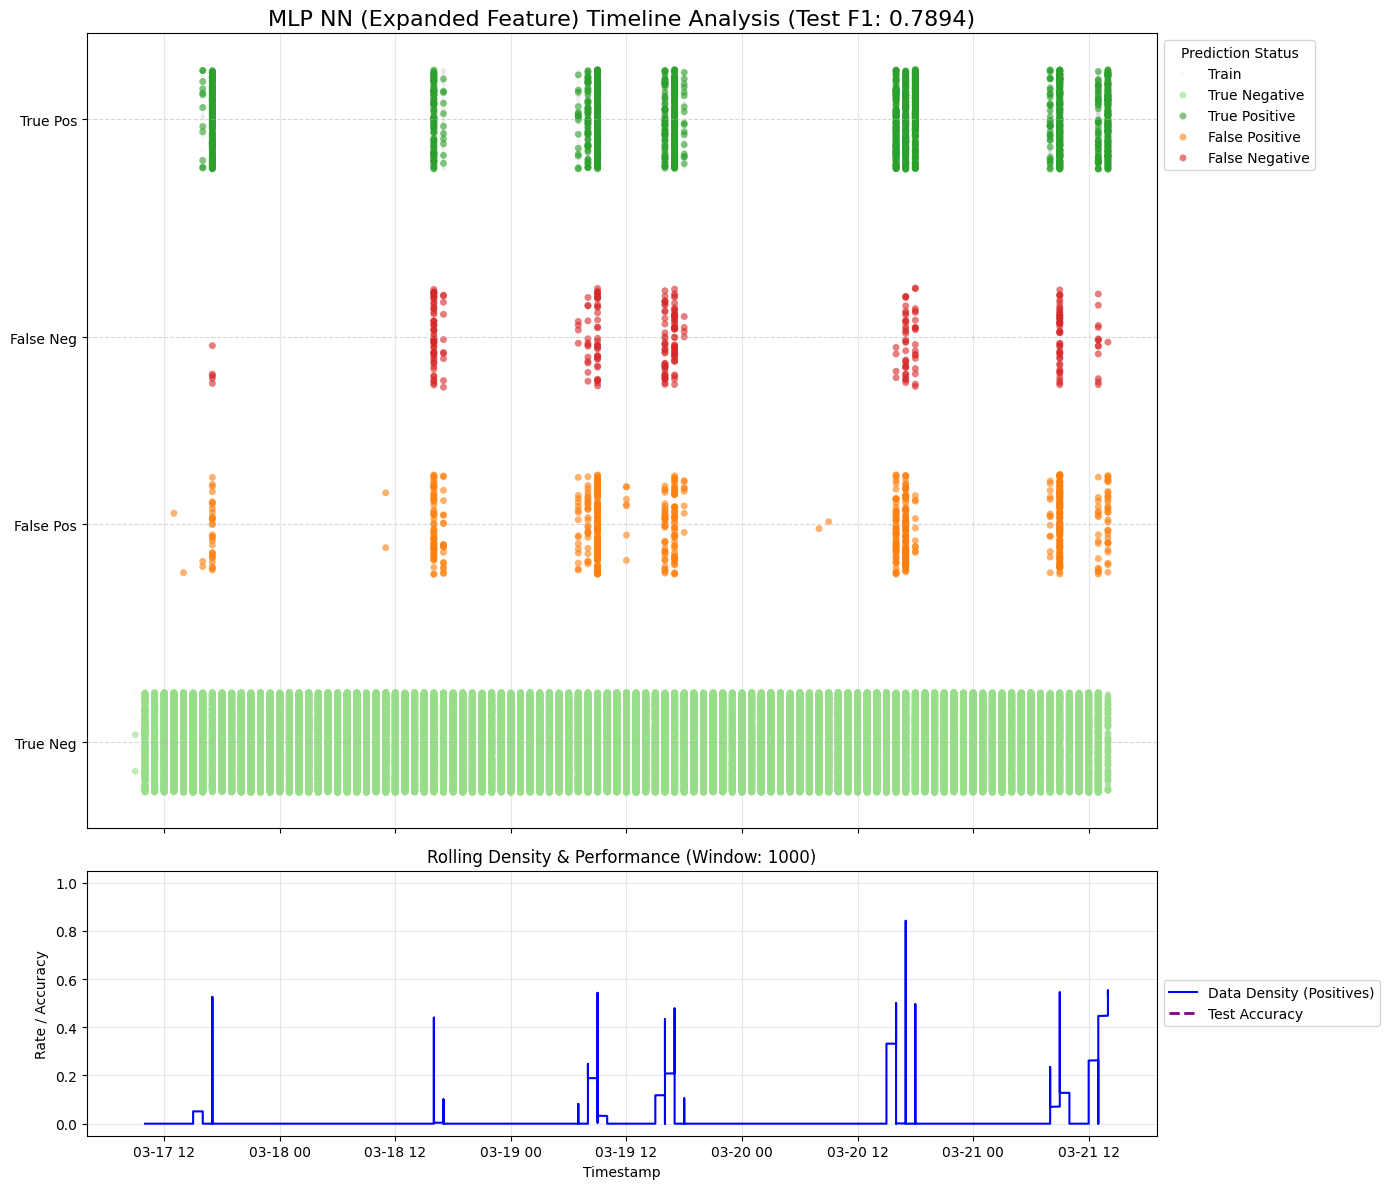

In [ ]:
import ast

print(f"Total features: {len(expanded_features)}")
print("Features:", expanded_features)

X_exp = df[expanded_features].copy()
y_exp = df['is_simulation'].copy()

# Fix the 'confidence' column which contains string lists like '[]'
def parse_confidence(val):
    if pd.isna(val): return 0.0
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return 0.0
    if isinstance(val, list):
        return float(max(val)) if len(val) > 0 else 0.0
    try:
        return float(val)
    except:
        return 0.0

if 'confidence' in X_exp.columns:
    X_exp['confidence'] = X_exp['confidence'].apply(parse_confidence)

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

# Scale features
scaler_exp = StandardScaler()
binary_cols = sentinel_species_cols + ['Eerie_Silence']
features_to_scale_exp = [f for f in expanded_features if f not in binary_cols]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale_exp] = scaler_exp.fit_transform(X_train_exp[features_to_scale_exp])
X_test_exp_scaled[features_to_scale_exp] = scaler_exp.transform(X_test_exp[features_to_scale_exp])

mlp_exp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_exp.fit(X_train_exp_scaled, y_train_exp)
y_pred_proba_exp = mlp_exp.predict_proba(X_test_exp_scaled)[:, 1]

print(f"\nMLP {len(expanded_features)} Features ROC-AUC: {roc_auc_score(y_test_exp, y_pred_proba_exp):.4f}")

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_exp = 0
best_thresh_exp = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_exp >= thresh).astype(int)
    f1 = f1_score(y_test_exp, y_pred)
    if f1 > best_f1_exp:
        best_f1_exp = f1
        best_thresh_exp = thresh

y_pred_exp = (y_pred_proba_exp >= best_thresh_exp).astype(int)
print(f"Best threshold: {best_thresh_exp:.2f}, F1: {best_f1_exp:.3f}")
print(classification_report(y_test_exp, y_pred_exp))

visualize_model_performance(
    df=df,              # The original dataframe (for timestamps)
    y_train=y_train_exp,    # The training labels with indices
    y_test=y_test_exp,      # The test labels with indices
    y_pred=y_pred_exp,  # The predictions you just generated
    model_name="MLP NN (Expanded Feature)"
)

#### Advanced Sythetic Oversampling Techniques

In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

# Import the advanced oversampling techniques
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTETomek

# --- 1. Base Preprocessing ---
expanded_features = [
    'Spectral RMS Energy', 'Spectral Contrast', 'Spectral Flatness', 'Spectral Bandwidth',
    'Spectral Rolloff (85%)', 'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13',
    'Myiothlypis fulvicauda_Buff-rumped Warbler', 'Habia atrimaxillaris_Black-cheeked Ant-Tanager',
    'Thamnophilus bridgesi_Black-hooded Antshrike', 'Tinamus major_Great Tinamou',
    'Patagioenas nigrirostris_Short-billed Pigeon', 'Ramphastos ambiguus_Yellow-throated Toucan',
    'Cyanoloxia cyanoides_Blue-black Grosbeak', 'Lipaugus unirufus_Rufous Piha',
    'Threnetes ruckeri_Band-tailed Barbthroat', 'Ara macao_Scarlet Macaw',
    'hour_sin', 'hour_cos', 'Eerie_Silence', 'Volume_Wind_Ratio', 'Volume_Spike_15s',
    'Temperature', 'Humidity', 'Windspeed', 'Human Activity Score', 'confidence'
]

X_exp = df[expanded_features].copy()
y_exp = df['is_simulation'].copy()

def parse_confidence(val):
    if pd.isna(val): return 0.0
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return 0.0
    if isinstance(val, list):
        return float(max(val)) if len(val) > 0 else 0.0
    try:
        return float(val)
    except:
        return 0.0

if 'confidence' in X_exp.columns:
    X_exp['confidence'] = X_exp['confidence'].apply(parse_confidence)

# Standard Split
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

# Scale features
scaler_exp = StandardScaler()
sentinel_species_cols = [col for col in expanded_features if "_" in col and "MFCC" not in col and col not in ['Eerie_Silence', 'Volume_Wind_Ratio', 'Volume_Spike_15s', 'Human Activity Score']]
binary_cols = sentinel_species_cols + ['Eerie_Silence']
features_to_scale_exp = [f for f in expanded_features if f not in binary_cols]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale_exp] = scaler_exp.fit_transform(X_train_exp[features_to_scale_exp])
X_test_exp_scaled[features_to_scale_exp] = scaler_exp.transform(X_test_exp[features_to_scale_exp])

# --- 2. Define a Helper Function for Evaluation ---
def train_and_evaluate_mlp(X_train, y_train, X_test, y_test, model_name):
    print(f"\n{'='*50}")
    print(f"Training and Evaluating: {model_name}")
    print(f"{'='*50}")

    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    mlp.fit(X_train, y_train)
    y_pred_proba = mlp.predict_proba(X_test)[:, 1]

    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1, best_thresh = 0, 0.5
    for thresh in thresholds:
        f1 = f1_score(y_test, (y_pred_proba >= thresh).astype(int))
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh

    y_pred_final = (y_pred_proba >= best_thresh).astype(int)
    print(f"Best threshold: {best_thresh:.2f}, F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred_final))

    # Fix for KeyError: only attempt visualization if training indices exist in the original df
    if all(idx in df.index for idx in y_train.index):
        visualize_model_performance(df=df, y_train=y_train, y_test=y_test, y_pred=y_pred_final, model_name=model_name)
    else:
        print("\n[Note] Training set contains synthetic samples from SMOTE. Timeline visualization skipped for training set to avoid index errors.")
        # Optional: You can still visualize just the test set if needed by modifying the visualization function

    return mlp

# --- 3. Apply Borderline-SMOTE ---
print("\nApplying Borderline-SMOTE to training data...")
bsmote = BorderlineSMOTE(random_state=42)
X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train_exp_scaled, y_train_exp)

mlp_bsmote = train_and_evaluate_mlp(X_train_bsmote, y_train_bsmote, X_test_exp_scaled, y_test_exp, "MLP NN (Borderline-SMOTE)")

# --- 4. Apply SMOTE + Tomek Links ---
print("\nApplying SMOTE + Tomek Links to training data...")
smtomek = SMOTETomek(random_state=42)
X_train_smtomek, y_train_smtomek = smtomek.fit_resample(X_train_exp_scaled, y_train_exp)

mlp_smtomek = train_and_evaluate_mlp(X_train_smtomek, y_train_smtomek, X_test_exp_scaled, y_test_exp, "MLP NN (SMOTE + Tomek)")


Applying Borderline-SMOTE to training data...

Training and Evaluating: MLP NN (Borderline-SMOTE)
ROC-AUC: 0.9958
Best threshold: 0.80, F1: 0.791
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     91156
           1       0.71      0.89      0.79      2342

    accuracy                           0.99     93498
   macro avg       0.85      0.94      0.89     93498
weighted avg       0.99      0.99      0.99     93498


[Note] Training set contains synthetic samples from SMOTE. Timeline visualization skipped for training set to avoid index errors.

Applying SMOTE + Tomek Links to training data...

Training and Evaluating: MLP NN (SMOTE + Tomek)
ROC-AUC: 0.9966
Best threshold: 0.85, F1: 0.797
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     91156
           1       0.71      0.92      0.80      2342

    accuracy                           0.99     93498
   macro avg       0.85      0

#### MLP performance visualization

Calculating permutation importance...


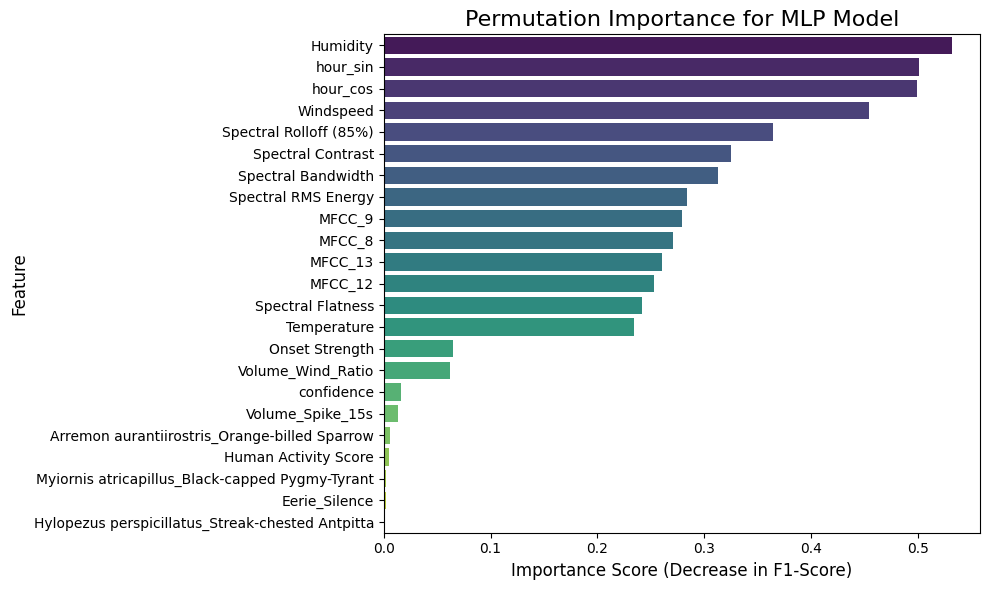

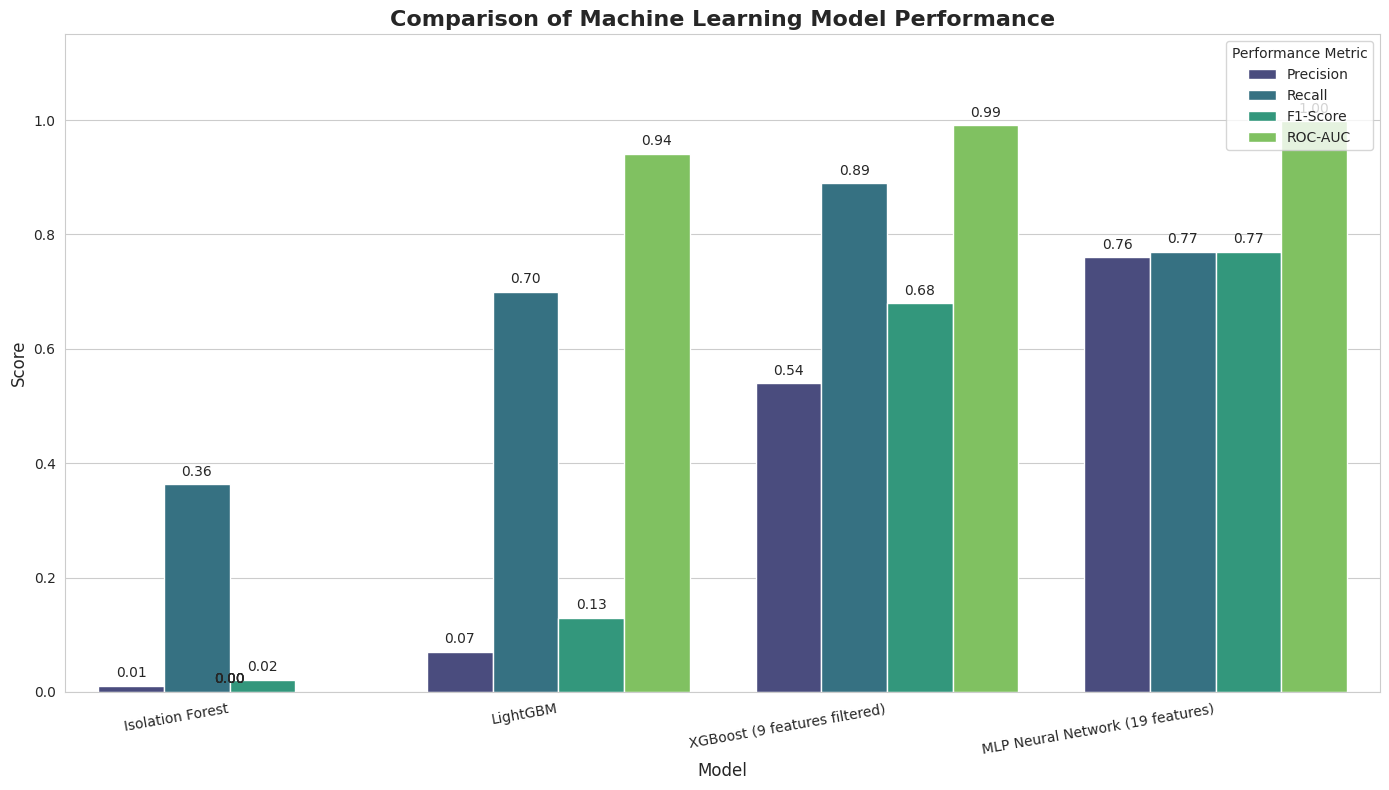

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plot_permutation_importance(
    model=mlp_exp,
    X_test=X_test_exp_scaled,  # Use the scaled test data
    y_test=y_test_exp,  # Use the test labels
    feature_names=expanded_features, # This list must match the columns in X_test_mlp
    title='Permutation Importance for MLP Model'
)

data = {
    'Model': [
        'Isolation Forest',
        'LightGBM',
        'XGBoost (9 features filtered)',
        'MLP Neural Network (23 features)'
    ],
    'Precision': [0.011, 0.07, 0.54, 0.76],  # <-- Replace with your Precision scores
    'Recall':    [0.363, 0.70, 0.89, 0.77],  # <-- Replace with your Recall scores
    'F1-Score':  [0.021, 0.13, 0.68, 0.77],  # <-- Replace with your F1-Scores
    'ROC-AUC':   [np.nan, 0.9413, 0.9908, 0.9983] # <-- Replace with your ROC-AUC scores (use np.nan for Isolation Forest)
}

# --------------------------------------------------------------------
# ---> STEP 2: RUN THE REST OF THE SCRIPT (No changes needed) <---
# --------------------------------------------------------------------

df_metrics = pd.DataFrame(data)

# Melt the DataFrame to a long format suitable for plotting
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Set the visual style and figure size for the chart
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

# Create the bar plot using seaborn
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

# Add the score labels on top of each bar for clarity
for p in ax.patches:
    # Check if the height is a valid number before adding the label
    if not np.isnan(p.get_height()):
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10)

# Set the titles and labels for the chart
plt.title('Comparison of Machine Learning Model Performance', fontsize=16, weight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=10, ha='right')
plt.ylim(0, 1.15) # Adjust y-axis to make space for labels above the bars
plt.legend(title='Performance Metric', loc='upper right')
plt.tight_layout()

# Save the plot as an image file and display it
plt.savefig('model_performance_comparison.png')
plt.show()

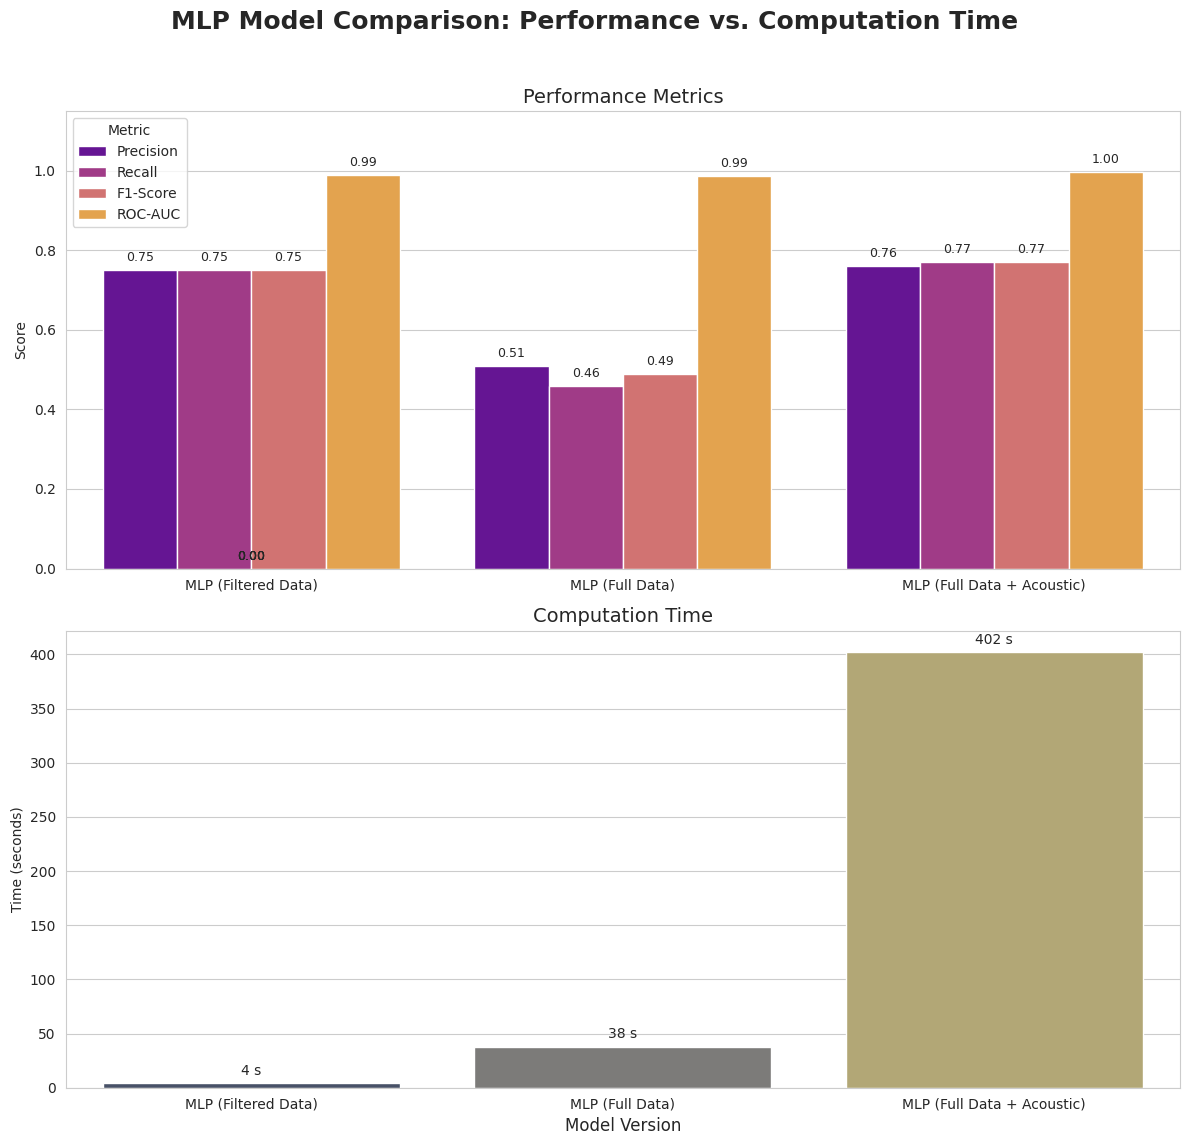

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---> STEP 1: UPDATE YOUR METRICS HERE <---
# Replace the placeholder numbers below with the actual results from your three MLP models.
# Make sure to use the scores for the POSITIVE class (label '1').

data = {
    'Model': [
        'MLP (Filtered Data)',
        'MLP (Full Data)',
        'MLP (Full Data + Acoustic)'
    ],
    'Precision': [0.75, 0.51, 0.76],  # <-- Replace with your Precision scores
    'Recall':    [0.75, 0.46, 0.77],  # <-- Replace with your Recall scores
    'F1-Score':  [0.75, 0.49, 0.77],  # <-- Replace with your F1-Scores
    'ROC-AUC':   [0.9898, 0.9877, 0.9983],  # <-- Replace with your ROC-AUC scores
    'Time (s)':  [4, 38, 402]          # <-- These are your computation times in seconds
}


df_mlp = pd.DataFrame(data)

# Set the visual style for the charts
sns.set_style("whitegrid")

# Create a figure with two vertically stacked subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
fig.suptitle('MLP Model Comparison: Performance vs. Computation Time', fontsize=18, weight='bold')

# --- Top Plot: Performance Metrics ---
df_perf = df_mlp.melt(id_vars='Model', value_vars=['Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                      var_name='Metric', value_name='Score')

ax1 = sns.barplot(data=df_perf, x='Model', y='Score', hue='Metric', ax=axes[0], palette='plasma')
ax1.set_title('Performance Metrics', fontsize=14)
ax1.set_xlabel('') # Remove x-axis label for the top plot
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1.15)
ax1.legend(title='Metric')

# Add score labels on top of each bar for the performance plot
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.2f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points',
                 fontsize=9)

# --- Bottom Plot: Computation Time ---
ax2 = sns.barplot(data=df_mlp, x='Model', y='Time (s)', ax=axes[1], palette='cividis')
ax2.set_title('Computation Time', fontsize=14)
ax2.set_xlabel('Model Version', fontsize=12)
ax2.set_ylabel('Time (seconds)')

# Add time labels on top of each bar for the time plot
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0f} s',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9),
                 textcoords='offset points',
                 fontsize=10)

# Adjust the layout to prevent titles and labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust rect for the main title (suptitle)

# Save the final chart as an image file and display it
plt.savefig('mlp_model_comparison.png')
plt.show()

### Individual Audio_Moth Analysis


Processing MLP (Expanded) for: Audio_Moth_1
Data Prepared: Train size: 89347, Test size: 22337
Train sim rate: 0.99%, Test sim rate: 0.98%

MLP 23 Features ROC-AUC: 0.9982
Best threshold: 0.60, F1: 0.777
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22117
           1       0.87      0.70      0.78       220

    accuracy                           1.00     22337
   macro avg       0.93      0.85      0.89     22337
weighted avg       1.00      1.00      1.00     22337

--- Calculating Permutation Importance for Audio_Moth_1 ---
Calculating permutation importance...


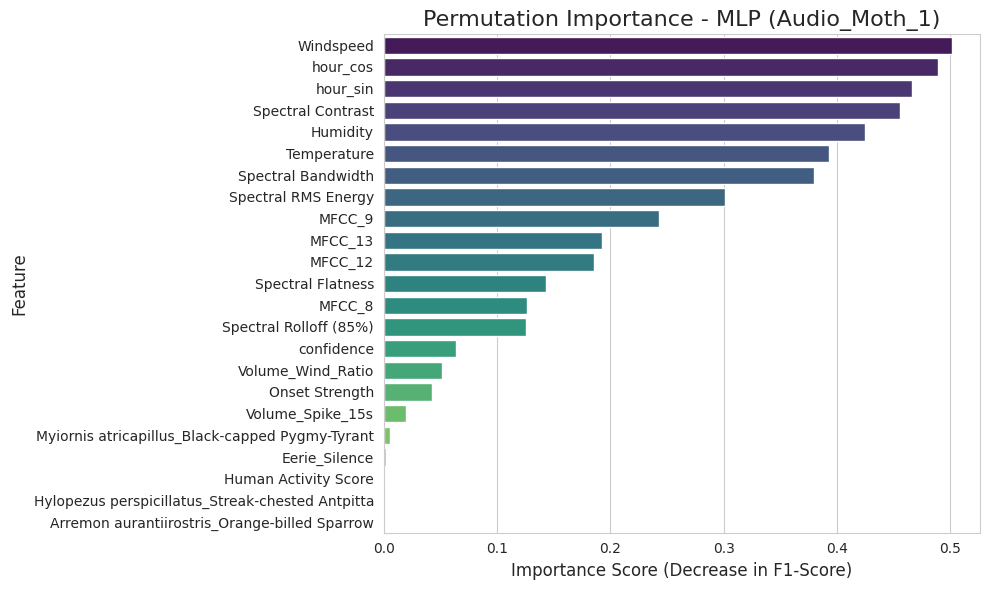


Processing MLP (Expanded) for: Audio_Moth_2
Data Prepared: Train size: 88696, Test size: 22174
Train sim rate: 1.26%, Test sim rate: 1.26%

MLP 23 Features ROC-AUC: 0.9987
Best threshold: 0.50, F1: 0.837
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21894
           1       0.81      0.87      0.84       280

    accuracy                           1.00     22174
   macro avg       0.90      0.93      0.92     22174
weighted avg       1.00      1.00      1.00     22174

--- Calculating Permutation Importance for Audio_Moth_2 ---
Calculating permutation importance...


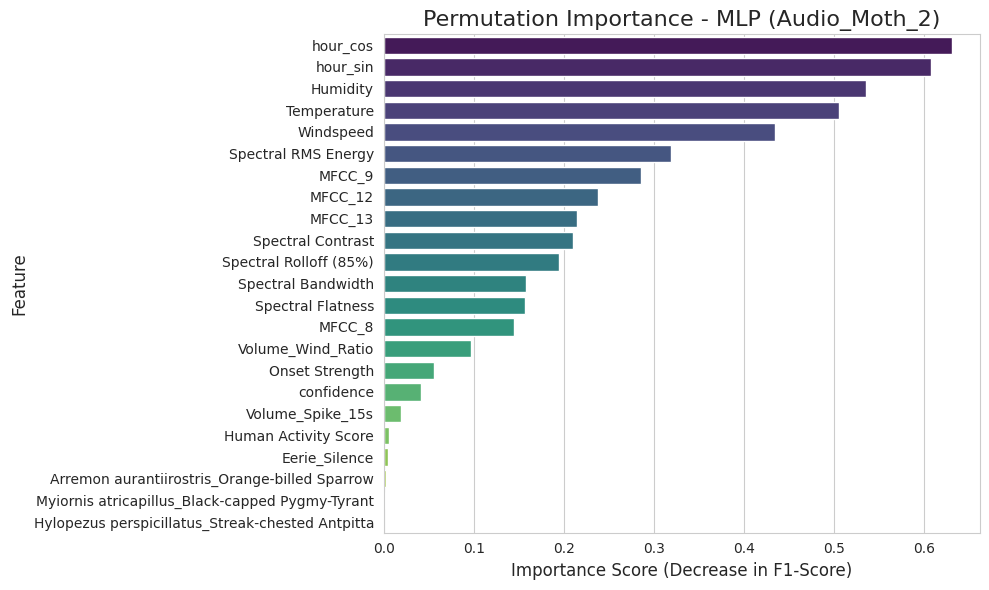


Processing MLP (Expanded) for: Audio_Moth_3
Data Prepared: Train size: 44636, Test size: 11160
Train sim rate: 1.08%, Test sim rate: 1.08%

MLP 23 Features ROC-AUC: 0.9973
Best threshold: 0.50, F1: 0.714
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11040
           1       0.65      0.79      0.71       120

    accuracy                           0.99     11160
   macro avg       0.82      0.89      0.86     11160
weighted avg       0.99      0.99      0.99     11160

--- Calculating Permutation Importance for Audio_Moth_3 ---
Calculating permutation importance...


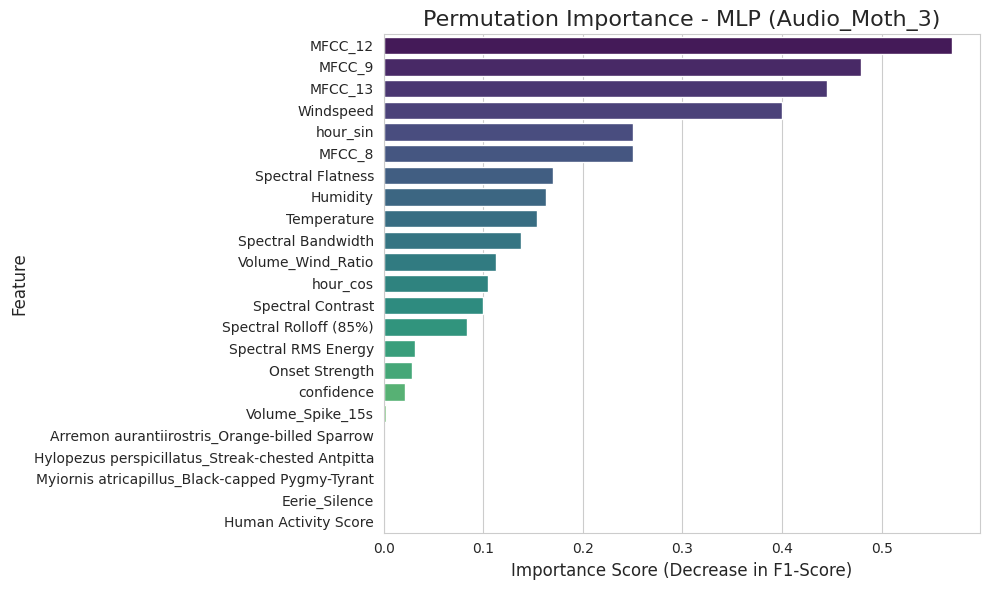


Processing MLP (Expanded) for: Audio_Moth_4
Data Prepared: Train size: 95480, Test size: 23870
Train sim rate: 2.56%, Test sim rate: 2.56%

MLP 23 Features ROC-AUC: 0.9971
Best threshold: 0.60, F1: 0.818
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     23259
           1       0.84      0.79      0.82       611

    accuracy                           0.99     23870
   macro avg       0.92      0.89      0.91     23870
weighted avg       0.99      0.99      0.99     23870

--- Calculating Permutation Importance for Audio_Moth_4 ---
Calculating permutation importance...


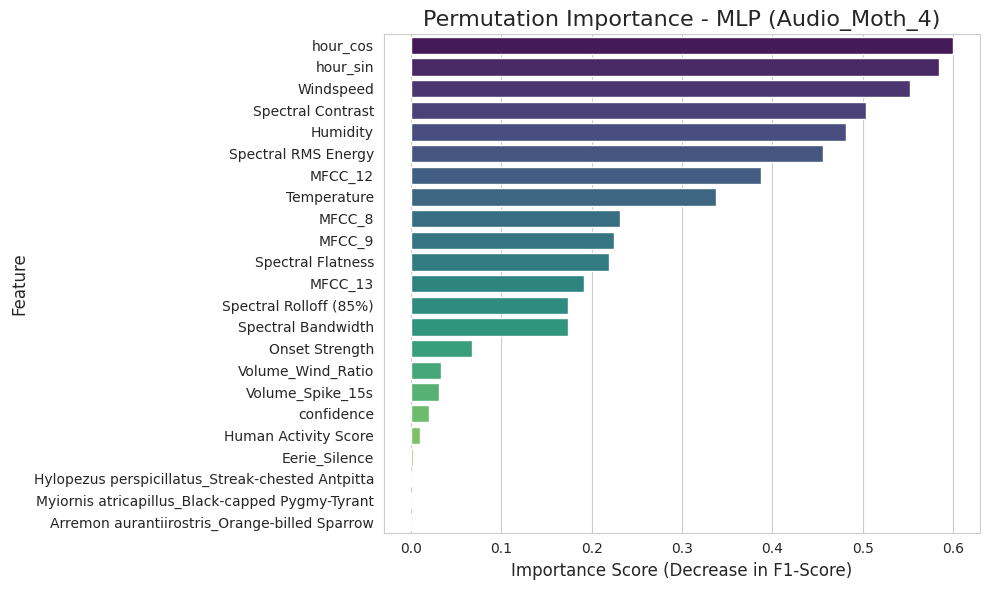


Processing MLP (Expanded) for: Audio_Moth_5
Data Prepared: Train size: 95117, Test size: 23780
Train sim rate: 3.15%, Test sim rate: 3.15%

MLP 23 Features ROC-AUC: 0.9957
Best threshold: 0.40, F1: 0.798
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     23031
           1       0.77      0.83      0.80       749

    accuracy                           0.99     23780
   macro avg       0.88      0.91      0.90     23780
weighted avg       0.99      0.99      0.99     23780

--- Calculating Permutation Importance for Audio_Moth_5 ---
Calculating permutation importance...


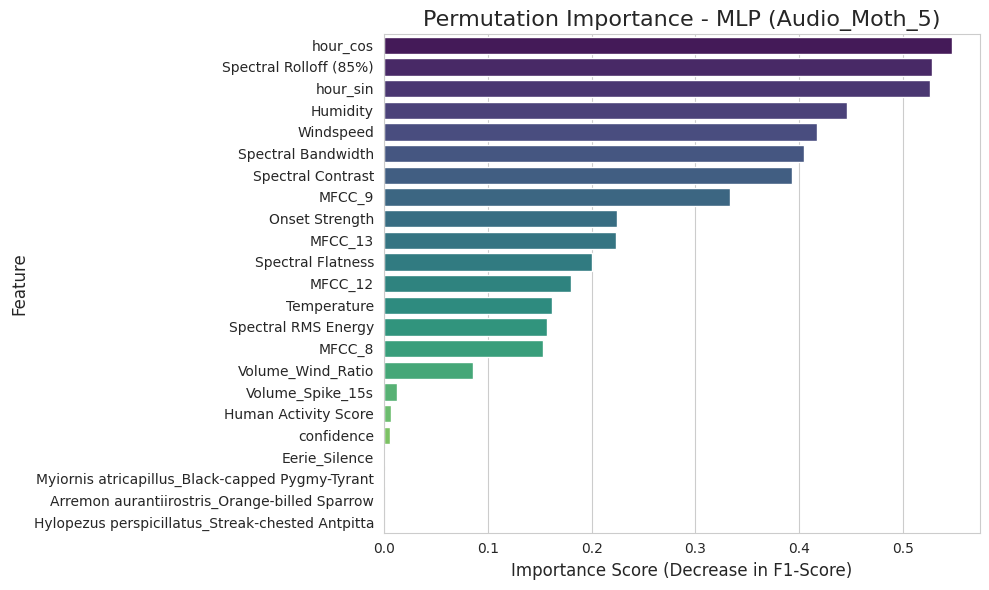


Processing MLP (Expanded) for: Audio_Moth_6
Data Prepared: Train size: 94045, Test size: 23512
Train sim rate: 3.24%, Test sim rate: 3.24%

MLP 23 Features ROC-AUC: 0.9955
Best threshold: 0.45, F1: 0.815
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     22751
           1       0.80      0.83      0.82       761

    accuracy                           0.99     23512
   macro avg       0.90      0.91      0.90     23512
weighted avg       0.99      0.99      0.99     23512

--- Calculating Permutation Importance for Audio_Moth_6 ---
Calculating permutation importance...


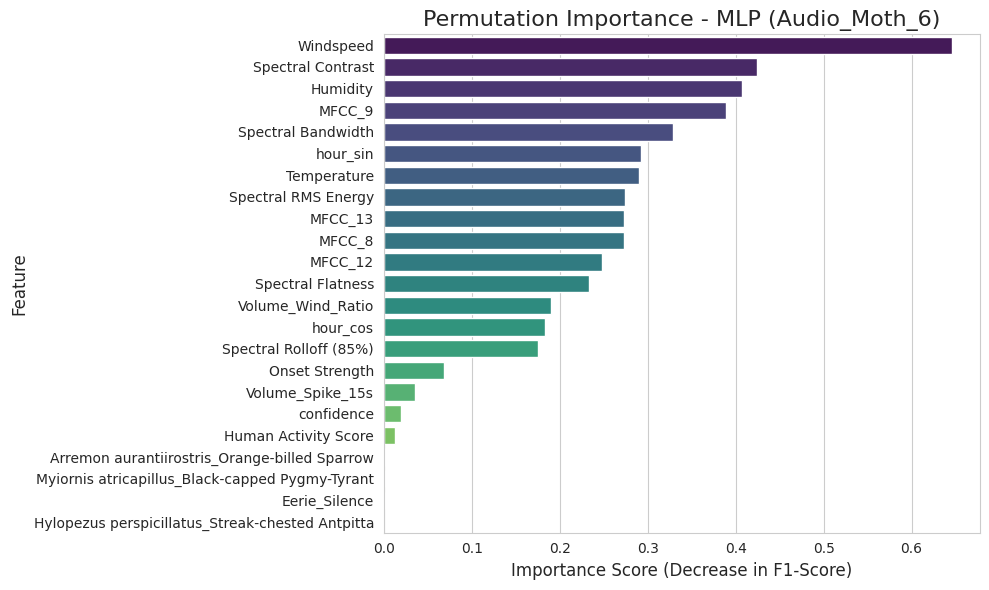


FINAL SUMMARY FOR MLP (EXPANDED) ACROSS ALL DEVICES
         device           model  f1_score  roc_auc  precision  recall  \
0  Audio_Moth_1  MLP (Expanded)     0.777    0.998      0.866   0.705   
1  Audio_Moth_2  MLP (Expanded)     0.837    0.999      0.805   0.871   
2  Audio_Moth_3  MLP (Expanded)     0.714    0.997      0.651   0.792   
3  Audio_Moth_4  MLP (Expanded)     0.818    0.997      0.843   0.794   
4  Audio_Moth_5  MLP (Expanded)     0.798    0.996      0.769   0.830   
5  Audio_Moth_6  MLP (Expanded)     0.815    0.996      0.799   0.832   

   best_threshold  test_sim_rate  
0            0.60          0.010  
1            0.50          0.013  
2            0.50          0.011  
3            0.60          0.026  
4            0.40          0.031  
5            0.45          0.032  


In [ ]:
import ast

# Set this to the feature list you want to use
FEATURE_COLUMNS = expanded_features

# Define your devices and data columns
DEVICE_COLUMN = 'recorder_id'     # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation' # The column in 'df' with the 0/1 target

# --- FIX: Parse confidence on the main df before processing ---
def parse_confidence(val):
    if pd.isna(val): return 0.0
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return 0.0
    if isinstance(val, list):
        return float(max(val)) if len(val) > 0 else 0.0
    try:
        return float(val)
    except:
        return 0.0

if 'confidence' in df.columns:
    df['confidence'] = df['confidence'].apply(parse_confidence)

# --- 3. Helper Functions (Copied from previous steps) ---

def get_device_data_custom_scaled(df, device_name, device_col, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Filters, splits, and custom-scales data for a single device.
    This function scales only non-boolean features.
    """
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty:
        print(f"No data found for {device_name}.")
        return None, None, None, None

    X_device = device_df[feature_cols]
    y_device = device_df[target_col]

    if X_device.shape[0] < 10:
        print(f"Insufficient data for {device_name} (found {X_device.shape[0]} rows).")
        return None, None, None, None

    stratify_param = y_device if y_device.nunique() > 1 else None
    if stratify_param is None:
        print(f"Warning: Only one class present. Splitting without stratification.")

    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # Fix scaling logic
    binary_cols = sentinel_species_cols + ['Eerie_Silence']
    features_to_scale = [f for f in feature_cols if f not in binary_cols]

    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh

    return best_f1, best_threshold

# --- 4. Main Loop to Run MLP ---

all_results = []

for moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"Processing MLP (Expanded) for: {moth_name}")
    print("="*80)

    # --- Get Data ---
    # We pass the FULL 'df' to the function
    data_pack = get_device_data_custom_scaled(
        df, # <-- Using the full, original DataFrame
        moth_name,
        DEVICE_COLUMN,
        FEATURE_COLUMNS, # <-- Using expanded_features
        TARGET_COLUMN,
        test_size=0.2    # <-- Matching your 0.2 test size
    )

    X_train_scaled, X_test_scaled, y_train, y_test = data_pack

    # --- Add Checks ---
    if X_train_scaled is None:
        print(f"Skipping {moth_name} due to insufficient data.")
        all_results.append({
            'device': moth_name, 'model': 'MLP (Expanded)', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue

    if y_train.nunique() < 2:
        print(f"Skipping {moth_name}: Training data has only one class (no positive samples).")
        all_results.append({
            'device': moth_name, 'model': 'MLP (Expanded)', 'f1_score': None,
            'roc_auc': None, 'precision': None, 'recall': None
        })
        continue
    # --- End Checks ---

    print(f"Data Prepared: Train size: {len(X_train_scaled)}, Test size: {len(X_test_scaled)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Train MLP Model ---
    # (Using the exact parameters you provided)
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    mlp_model.fit(X_train_scaled, y_train)
    y_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

    # --- Evaluate ---
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"\nMLP {len(FEATURE_COLUMNS)} Features ROC-AUC: {roc_auc:.4f}")

    # Find best threshold
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    print(f"Best threshold: {best_thresh:.2f}, F1: {best_f1:.3f}")

    # Get final predictions and classification report
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)
    print(classification_report(y_test, y_pred_final, zero_division=0))

    # Permutation Feature importance
    print(f"--- Calculating Permutation Importance for {moth_name} ---")
    plot_permutation_importance(
        model=mlp_model,
        X_test=X_test_scaled,
        y_test=y_test,
        feature_names=FEATURE_COLUMNS, # This is your 'expanded_features' list
        title=f"Permutation Importance - MLP ({moth_name})"
    )

    # Store results
    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    all_results.append({
        'device': moth_name,
        'model': 'MLP (Expanded)',
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_sim_rate': y_test.mean()
    })

# --- 5. Final Summary ---
print(f"\n" + "="*80)
print("FINAL SUMMARY FOR MLP (EXPANDED) ACROSS ALL DEVICES")
print("="*80)

summary_df = pd.DataFrame(all_results)
print(summary_df.round(3))


--- Pre-processing data for all devices (from full dataset) ---
  -> Stored data for Audio_Moth_1 (Train: 89347, Test: 22337)
  -> Stored data for Audio_Moth_2 (Train: 88696, Test: 22174)
  -> Stored data for Audio_Moth_3 (Train: 44636, Test: 11160)
  -> Stored data for Audio_Moth_4 (Train: 95480, Test: 23870)
  -> Stored data for Audio_Moth_5 (Train: 95117, Test: 23780)
  -> Stored data for Audio_Moth_6 (Train: 94045, Test: 23512)
--- Data pre-processing complete ---

TRAINING Model on: Audio_Moth_1 (MLP Expanded)
--- Testing 'Audio_Moth_1' model on all devices: ---
  -> TESTED on Audio_Moth_1: F1 = 0.779 (P: 0.858, R: 0.714)
  -> TESTED on Audio_Moth_2: F1 = 0.470 (P: 0.443, R: 0.500)
  -> TESTED on Audio_Moth_3: F1 = 0.512 (P: 0.410, R: 0.683)
  -> TESTED on Audio_Moth_4: F1 = 0.208 (P: 0.185, R: 0.237)
  -> TESTED on Audio_Moth_5: F1 = 0.261 (P: 0.212, R: 0.340)
  -> TESTED on Audio_Moth_6: F1 = 0.044 (P: 0.049, R: 0.039)

TRAINING Model on: Audio_Moth_2 (MLP Expanded)
--- Testing

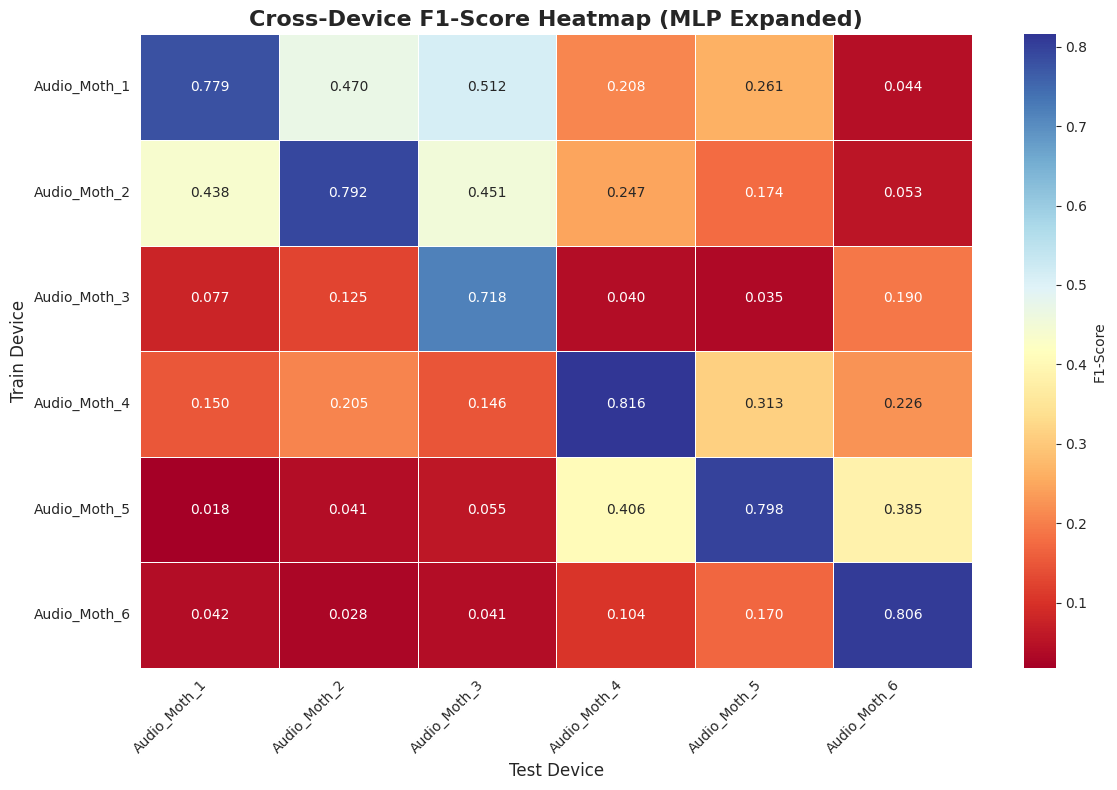

In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Define Your Devices and Features ---
# Using the correct feature lists including Patrick's features and sentinel species
expanded_features = core_features + \
    sentinel_species_cols + \
    patrick_features + \
    [
    'Temperature', 'Humidity', 'Windspeed',
    'Human Activity Score', 'confidence'
]

audio_moths = [
    'Audio_Moth_1', 'Audio_Moth_2', 'Audio_Moth_3',
    'Audio_Moth_4', 'Audio_Moth_5', 'Audio_Moth_6'
]

DEVICE_COLUMN = 'recorder_id'
FEATURE_COLUMNS = expanded_features # <-- Using your expanded feature list
TARGET_COLUMN = 'is_simulation'

# --- FIX: Parse confidence on the main df before processing ---
def parse_confidence(val):
    if pd.isna(val): return 0.0
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except:
            return 0.0
    if isinstance(val, list):
        return float(max(val)) if len(val) > 0 else 0.0
    try:
        return float(val)
    except:
        return 0.0

if 'confidence' in df.columns:
    df['confidence'] = df['confidence'].apply(parse_confidence)

# --- 2. Helper Functions (From your code) ---

def get_device_data_custom_scaled(df, device_name, device_col, feature_cols, target_col, test_size=0.2, random_state=42):
    """
    Filters, splits, and custom-scales data for a single device.
    This function scales only non-boolean features.
    """
    device_df = df[df[device_col] == device_name].copy()

    if device_df.empty: return None, None, None, None
    X_device = device_df[feature_cols]
    y_device = device_df[target_col]
    if X_device.shape[0] < 10: return None, None, None, None

    stratify_param = y_device if y_device.nunique() > 1 else None

    # Split the raw (unscaled) data first
    X_train, X_test, y_train, y_test = train_test_split(
        X_device, y_device,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_param
    )

    # --- Custom Scaling Logic ---
    binary_cols = sentinel_species_cols + ['Eerie_Silence']
    features_to_scale = [f for f in feature_cols if f not in binary_cols]
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    # Fit on train and transform both train and test
    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

    return X_train_scaled, X_test_scaled, y_train, y_test

def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Pre-process and Cache Data for All Devices ---
data_bundles = {}
print("\n--- Pre-processing data for all devices (from full dataset) ---")
for moth_name in audio_moths:
    data_pack = get_device_data_custom_scaled(
        df, # <-- Using the full, original DataFrame
        moth_name,
        DEVICE_COLUMN,
        FEATURE_COLUMNS, # Using expanded_features
        TARGET_COLUMN,
        test_size=0.2    # <-- Matching your 0.2 test size
    )

    data_bundles[moth_name] = data_pack

    if data_pack[0] is not None:
        print(f"  -> Stored data for {moth_name} (Train: {len(data_pack[0])}, Test: {len(data_pack[1])})")
    else:
        print(f"  -> No/Insufficient data for {moth_name}")
print("--- Data pre-processing complete ---")


# --- 4. Main Nested Loop for Cross-Device Testing ---

all_cross_device_results = []

# --- Outer Loop: TRAIN on this device ---
for train_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"TRAINING Model on: {train_moth_name} (MLP Expanded)")
    print("="*80)

    # Get the training data for this moth
    X_train_scaled, _, y_train, _ = data_bundles[train_moth_name]

    # --- Check if training is possible ---
    if X_train_scaled is None:
        print(f"Skipping training for {train_moth_name}: Insufficient data.")
        continue

    if y_train.nunique() < 2:
        print(f"Skipping training for {train_moth_name}: Training data has only one class.")
        continue

    # --- Train the MLP Model ---
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    mlp_model.fit(X_train_scaled, y_train)

    # --- Inner Loop: TEST on this device ---
    print(f"--- Testing '{train_moth_name}' model on all devices: ---")
    for test_moth_name in audio_moths:

        # Get the TEST data for the inner moth
        _, X_test_scaled, _, y_test = data_bundles[test_moth_name]

        # --- Check if testing is possible ---
        if X_test_scaled is None or y_test is None:
            print(f"  -> Skipping test on {test_moth_name}: Insufficient test data.")
            continue

        if y_test.nunique() < 2:
            print(f"  -> Skipping test on {test_moth_name}: Test data has only one class.")
            continue

        # --- Test and Evaluate ---
        y_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

        best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
        y_pred_final = (y_pred_proba >= best_thresh).astype(int)

        sim_precision = precision_score(y_test, y_pred_final, zero_division=0)
        sim_recall = recall_score(y_test, y_pred_final, zero_division=0)

        print(f"  -> TESTED on {test_moth_name}: F1 = {best_f1:.3f} (P: {sim_precision:.3f}, R: {sim_recall:.3f})")

        all_cross_device_results.append({
            'train_device': train_moth_name,
            'test_device': test_moth_name,
            'f1_score': best_f1,
            'precision': sim_precision,
            'recall': sim_recall
        })

# --- 5. Final Summary ---
print(f"\n" + "="*80)
print("SUMMARY OF CROSS-DEVICE VALIDATION (MLP Expanded)")
print("="*80)

results_df_mlp = pd.DataFrame(all_cross_device_results)

# A pivot table is the best way to view this
print("--- F1-Score Heatmap (Train device = rows, Test device = columns) ---")
f1_pivot_mlp = results_df_mlp.pivot(
    index='train_device',
    columns='test_device',
    values='f1_score'
)
print(f1_pivot_mlp.round(3))

# --- 6. Generate Heatmap Visualization ---
print("\n--- Generating Heatmap ---")
plt.figure(figsize=(12, 8))
sns.heatmap(
    f1_pivot_mlp,
    annot=True,        # Show the F1-score numbers
    fmt=".3f",         # Format to 3 decimal places
    cmap="RdYlBu",     # Color map: Red (high/good) to Blue (low/bad)
    linewidths=.5,
    cbar_kws={'label': 'F1-Score'}
)
plt.title('Cross-Device F1-Score Heatmap (MLP Expanded)', fontsize=16, weight='bold')
plt.xlabel('Test Device', fontsize=12)
plt.ylabel('Train Device', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cross_device_f1_heatmap_mlp.png')
plt.show()

#### Cross Validation for original MLP NN with 3 Sentinel Species + 6 high ranking features + acoustic data using full data

In [ ]:

# --- 1. Data Preparation (Same as your code) ---

print(f"Total features: {len(expanded_features)}")

X_exp = df[expanded_features].copy()
y_exp = df['is_simulation'].copy()

# Identify features to scale (non-booleans)
features_to_scale_exp = [f for f in expanded_features if not f.startswith('is_')]

# --- 2. Cross-Validation Setup ---
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Lists to store the score from each fold
fold_f1_scores = []
fold_roc_auc_scores = []
fold_best_thresholds = []

print(f"\n--- Starting {N_SPLITS}-Fold Stratified Cross-Validation ---")

# --- 3. The Cross-Validation Loop ---
for fold, (train_index, test_index) in enumerate(skf.split(X_exp, y_exp)):
    print(f"\n" + "="*80)
    print(f"FOLD {fold + 1}/{N_SPLITS}")
    print("="*80)

    # --- A: Split data for this fold ---
    X_train, X_test = X_exp.iloc[train_index], X_exp.iloc[test_index]
    y_train, y_test = y_exp.iloc[train_index], y_exp.iloc[test_index]

    # --- B: Scale features (Fit *only* on train data) ---
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[features_to_scale_exp] = scaler.fit_transform(X_train[features_to_scale_exp])
    X_test_scaled[features_to_scale_exp] = scaler.transform(X_test[features_to_scale_exp])

    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

    # --- C: Initialize and Train Model (re-create for each fold) ---
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    mlp_model.fit(X_train_scaled, y_train)

    # --- D: Evaluate ---
    y_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

    fold_roc_auc = roc_auc_score(y_test, y_pred_proba)
    fold_roc_auc_scores.append(fold_roc_auc)

    # Find best threshold (your logic)
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f1_fold = 0
    best_thresh_fold = 0.5

    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        if f1 > best_f1_fold:
            best_f1_fold = f1
            best_thresh_fold = thresh

    fold_f1_scores.append(best_f1_fold)
    fold_best_thresholds.append(best_thresh_fold)

    print(f"Fold {fold+1} ROC-AUC: {fold_roc_auc:.4f}")
    print(f"Fold {fold+1} Best F1: {best_f1_fold:.3f} (at threshold {best_thresh_fold:.2f})")

# --- 4. Final Summary ---
print(f"\n" + "="*80)
print("Cross-Validation Summary (All 6 Moths Combined)")
print("="*80)
print(f"Average F1-Score:    {np.mean(fold_f1_scores):.4f} +/- {np.std(fold_f1_scores):.4f}")
print(f"Average ROC-AUC:     {np.mean(fold_roc_auc_scores):.4f} +/- {np.std(fold_roc_auc_scores):.4f}")
print(f"Average Best Threshold: {np.mean(fold_best_thresholds):.2f}")

Total features: 22

--- Starting 5-Fold Stratified Cross-Validation ---

FOLD 1/5
Train size: 507323, Test size: 126831
Fold 1 ROC-AUC: 0.9952
Fold 1 Best F1: 0.746 (at threshold 0.40)

FOLD 2/5
Train size: 507323, Test size: 126831
Fold 2 ROC-AUC: 0.9951
Fold 2 Best F1: 0.746 (at threshold 0.40)

FOLD 3/5
Train size: 507323, Test size: 126831
Fold 3 ROC-AUC: 0.9954
Fold 3 Best F1: 0.753 (at threshold 0.35)

FOLD 4/5
Train size: 507323, Test size: 126831
Fold 4 ROC-AUC: 0.9959
Fold 4 Best F1: 0.770 (at threshold 0.35)

FOLD 5/5
Train size: 507324, Test size: 126830
Fold 5 ROC-AUC: 0.9959
Fold 5 Best F1: 0.764 (at threshold 0.35)

Cross-Validation Summary (All 6 Moths Combined)
Average F1-Score:    0.7557 +/- 0.0096
Average ROC-AUC:     0.9955 +/- 0.0003
Average Best Threshold: 0.37


It seems that training model on individual audio moths were causing them to overfit, increasing performance but greatly reducing generalizability.

Future goals:
1. Use Leave-One-Device-Out (LODO) Cross-Validation
    - Train on a combined dataset of Moth_1, Moth_2, Moth_3, Moth_4, and Moth_5.
    - Test only on the held-out Moth_6.
    - Repeat this process 6 times, holding out a different moth each time.
    - All models performed worse compared to previous performance metrics
    - This suggests the 1) models either do not generalize well and performs poorly when introduced to a unfamiliar device, or 2) the different devices have unique qualities and cannot be generalized well from training with the other audio moths
    - Audio_Moth 5 and 6 are most similar to each other, which causes their f1 score to be higher during LODO
2. Feature Selection and Augmentation
    - more useful feature (from feature selection), more samples (from augmenting previous simulation samples)
3. Device specific validation for original model to see if a device is carrying the performance metric
    - Results are patchy at best, with some models that have audio moth 3, 5, and 6 being well predicted (MLP), while in others, audio moth 3 gets zero recall (Sentinel species XGBoost, probably due to its filtered dataset and audio moth three only having 52 test samples), others also show that Audio moth 1 has been carrying the performance (lightGBM)
4. standarize data across audio_moth
5. select other audio features
6. Rufous Piha
7. Spectacled Owl
8. how to represent sentinel species within each data point
9.
Further questions:



#### Per-device Validation

In [ ]:

# --- 1. Define Features and Device Info ---


DEVICE_COLUMN = 'recorder_id' # The column in 'df' with the moth names

# --- 2. Prepare Data (Your Original Code) ---
print(f"Total features: {len(expanded_features)}")
print("Features:", expanded_features)

X_exp = df[expanded_features].copy()
y_exp = df['is_simulation'].copy()

X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp, test_size=0.2, random_state=42, stratify=y_exp
)

# --- 3. (NEW) Get a DataFrame of the Test Set ---
# We use the index from X_test_exp to get the original rows from df.
# This df_test will have the device ID, true label, and features.
df_test = df.loc[X_test_exp.index].copy()

# --- 4. Scale Data (Your Original Code) ---
scaler_exp = StandardScaler()
features_to_scale_exp = [f for f in expanded_features if not f.startswith('is_')]

X_train_exp_scaled = X_train_exp.copy()
X_test_exp_scaled = X_test_exp.copy()
X_train_exp_scaled[features_to_scale_exp] = scaler_exp.fit_transform(X_train_exp[features_to_scale_exp])
X_test_exp_scaled[features_to_scale_exp] = scaler_exp.transform(X_test_exp[features_to_scale_exp])

# --- 5. Train MLP (Your Original Code) ---
mlp_exp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.01,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

print("\n--- Training MLP on all devices ---")
mlp_exp.fit(X_train_exp_scaled, y_train_exp)

# --- 6. Evaluate on ALL Test Data (Your Original Code) ---
y_pred_proba_exp = mlp_exp.predict_proba(X_test_exp_scaled)[:, 1]

print(f"\nMLP {len(expanded_features)} Features ROC-AUC (Overall): {roc_auc_score(y_test_exp, y_pred_proba_exp):.4f}")

# Find best threshold (based on overall test set)
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1_exp = 0
best_thresh_exp = 0.5

for thresh in thresholds:
    y_pred = (y_pred_proba_exp >= thresh).astype(int)
    f1 = f1_score(y_test_exp, y_pred)
    if f1 > best_f1_exp:
        best_f1_exp = f1
        best_thresh_exp = thresh

y_pred_exp = (y_pred_proba_exp >= best_thresh_exp).astype(int)
print(f"Best threshold (Overall): {best_thresh_exp:.2f}, F1: {best_f1_exp:.3f}")
print("\n--- Overall Test Set Performance (All Devices) ---")
print(classification_report(y_test_exp, y_pred_exp))


# --- 7. (NEW) Per-Device Evaluation Loop ---
print(f"\n" + "="*80)
print("PER-DEVICE PERFORMANCE BREAKDOWN (ON TEST SET)")
print("="*80)

# Add the final predictions to our test DataFrame
df_test['y_pred_final'] = y_pred_exp

per_device_results = []

for moth_name in audio_moths:
    # Filter the test set for *only* this moth's data
    moth_test_df = df_test[df_test[DEVICE_COLUMN] == moth_name]

    if moth_test_df.empty:
        print(f"\n--- {moth_name} ---")
        print("No test data available for this device.")
        continue

    # Get the true labels and predicted labels for this device
    y_true_device = moth_test_df['is_simulation']
    y_pred_device = moth_test_df['y_pred_final']

    # Calculate metrics
    f1 = f1_score(y_true_device, y_pred_device, zero_division=0)
    precision = precision_score(y_true_device, y_pred_device, zero_division=0)
    recall = recall_score(y_true_device, y_pred_device, zero_division=0)

    print(f"\n--- {moth_name} (Test Samples: {len(y_true_device)}) ---")
    print(f"F1: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")
    # print(classification_report(y_true_device, y_pred_device, zero_division=0))

    per_device_results.append({
        'device': moth_name,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'test_samples': len(y_true_device)
    })

# --- 8. (NEW) Final Summary Table ---
print(f"\n" + "="*80)
print("Per-Device Performance Summary")
print("="*80)
summary_df = pd.DataFrame(per_device_results)
print(summary_df.round(3))

Total features: 22
Features: ['Spectral Contrast', 'Spectral Flatness', 'Spectral Bandwidth', 'Spectral Rolloff (85%)', 'Onset Strength', 'MFCC_8', 'MFCC_9', 'MFCC_12', 'MFCC_13', 'Arremon aurantiirostris_Orange-billed Sparrow', 'Hylopezus perspicillatus_Streak-chested Antpitta', 'Myiornis atricapillus_Black-capped Pygmy-Tyrant', 'hour_sin', 'hour_cos', 'Eerie_Silence', 'Volume_Wind_Ratio', 'Volume_Spike_15s', 'Temperature', 'Humidity', 'Windspeed', 'Human Activity Score', 'confidence']

--- Training MLP on all devices ---

MLP 22 Features ROC-AUC (Overall): 0.9959
Best threshold (Overall): 0.40, F1: 0.770

--- Overall Test Set Performance (All Devices) ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    124089
           1       0.72      0.82      0.77      2742

    accuracy                           0.99    126831
   macro avg       0.86      0.91      0.88    126831
weighted avg       0.99      0.99      0.99    126831


PER-DE

#### LODO Validation

In [ ]:
# WARNING: Long runtime (1hr 30min+ on Google Colab pro T4 GPU)


DEVICE_COLUMN = 'recorder_id' # The column in 'df' with the moth names
TARGET_COLUMN = 'is_simulation'
FEATURES_TO_USE = expanded_features

# Identify which features to scale (all except the 'is_' boolean flags)
features_to_scale = [f for f in FEATURES_TO_USE if not f.startswith('is_')]

# --- 2. Helper Function ---
def find_best_threshold(y_true, y_pred_proba, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Finds the best classification threshold based on the F1-score.
    """
    best_f1 = 0
    best_threshold = 0.5
    for thresh in thresholds:
        y_pred = (y_pred_proba >= thresh).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
    return best_f1, best_threshold

# --- 3. Main LODO Cross-Validation Loop ---
all_lodo_results = []
print("--- Starting Leave-One-Device-Out (LODO) Validation for MLP ---")

for test_moth_name in audio_moths:
    print(f"\n" + "="*80)
    print(f"HOLDING OUT (Test Set): {test_moth_name}")
    print(f"TRAINING on all other 5 devices")
    print("="*80)

    # --- Create Train/Test splits based on device ---
    # Train set = all data *except* the hold-out device
    train_df = df[df[DEVICE_COLUMN] != test_moth_name].copy()
    # Test set = *only* the hold-out device
    test_df = df[df[DEVICE_COLUMN] == test_moth_name].copy()

    # --- Check for valid data ---
    if test_df.empty:
        print(f"Skipping {test_moth_name}: No data found for this device.")
        continue
    if train_df.empty:
        print(f"Skipping {test_moth_name}: No training data available.")
        continue

    # --- Separate Features and Target ---
    X_train_raw = train_df[FEATURES_TO_USE]
    y_train = train_df[TARGET_COLUMN]
    X_test_raw = test_df[FEATURES_TO_USE]
    y_test = test_df[TARGET_COLUMN]

    # Check for labels in train/test sets
    if y_train.nunique() < 2:
        print(f"Skipping {test_moth_name}: Training data has only one class.")
        continue
    if y_test.nunique() < 2:
        print(f"Skipping {test_moth_name}: Test data has only one class.")
        continue

    print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
    print(f"Train sim rate: {y_train.mean():.2%}, Test sim rate: {y_test.mean():.2%}")

    # --- Scale Data (Fit on Train, Transform Test) ---
    scaler = StandardScaler()

    X_train_scaled = X_train_raw.copy()
    X_test_scaled = X_test_raw.copy()

    X_train_scaled[features_to_scale] = scaler.fit_transform(X_train_raw[features_to_scale])
    X_test_scaled[features_to_scale] = scaler.transform(X_test_raw[features_to_scale])

    # --- Train MLP Model (from your code) ---
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        alpha=0.01,
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )

    mlp_model.fit(X_train_scaled, y_train)

    # --- Evaluate on Hold-Out Device ---
    y_pred_proba = mlp_model.predict_proba(X_test_scaled)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    best_f1, best_thresh = find_best_threshold(y_test, y_pred_proba)
    y_pred_final = (y_pred_proba >= best_thresh).astype(int)

    precision = precision_score(y_test, y_pred_final, zero_division=0)
    recall = recall_score(y_test, y_pred_final, zero_division=0)

    print(f"\n--- Results for held-out {test_moth_name} ---")
    print(f"F1: {best_f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, ROC-AUC: {roc_auc:.3f}")
    # print(classification_report(y_test, y_pred_final, zero_division=0))

    # Store results
    all_lodo_results.append({
        'held_out_device': test_moth_name,
        'f1_score': best_f1,
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'best_threshold': best_thresh,
        'test_samples': len(y_test)
    })

# --- 4. Final LODO Summary ---
print(f"\n" + "="*80)
print("LODO VALIDATION SUMMARY (MLP Expanded)")
print("="*80)

summary_df = pd.DataFrame(all_lodo_results)
print(summary_df.round(3))

print(f"\n" + "="*80)
print("Average LODO Performance")
print("="*80)
# Drop non-numeric columns before calculating mean
metrics_mean = summary_df.drop(columns=['held_out_device']).mean()
print(metrics_mean.round(3))

--- Starting Leave-One-Device-Out (LODO) Validation for MLP ---

HOLDING OUT (Test Set): Audio_Moth_1
TRAINING on all other 5 devices
Train size: 437173, Test size: 332192
Train sim rate: 1.19%, Test sim rate: 0.43%

--- Results for held-out Audio_Moth_1 ---
F1: 0.038, Precision: 0.036, Recall: 0.039, ROC-AUC: 0.925

HOLDING OUT (Test Set): Audio_Moth_2
TRAINING on all other 5 devices
Train size: 596430, Test size: 172935
Train sim rate: 0.87%, Test sim rate: 0.86%

--- Results for held-out Audio_Moth_2 ---
F1: 0.092, Precision: 0.079, Recall: 0.111, ROC-AUC: 0.934

HOLDING OUT (Test Set): Audio_Moth_3
TRAINING on all other 5 devices
Train size: 751305, Test size: 18060
Train sim rate: 0.88%, Test sim rate: 0.19%

--- Results for held-out Audio_Moth_3 ---
F1: 0.005, Precision: 0.003, Recall: 0.029, ROC-AUC: 0.902

HOLDING OUT (Test Set): Audio_MMoth_4
TRAINING on all other 5 devices
Skipping Audio_MMoth_4: No data found for this device.

HOLDING OUT (Test Set): Audio_Moth_5
TRAINING on